# Import libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Data Loading

In [39]:
# Load the dataset
df = pd.read_csv('../data/creditcard.csv')

# Initial Exploration (shape, info, head, describe)

In [6]:
# Explore the features available in your dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# Data Preprocessing / Cleaning / Quality Checks

- missing values
- duplicates
- outliers

In [10]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing values: {(df.isnull().sum().sum() / len(df)) * 100:.4f}%")


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0
Percentage of missing values: 0.0000%


No missing values found!

In [11]:
# Check for infinite values
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
print("Infinite values per column:")
print(inf_counts[inf_counts > 0])
if inf_counts.sum() == 0:
    print("No infinite values found.")


Infinite values per column:
Series([], dtype: int64)
No infinite values found.


## Checking the fraud to non-fraud ratio

In [12]:
# Count the occurrences of fraud and no fraud and print them
occ = df['Class'].value_counts()
print(occ)

# Print the ratio of fraud cases
print(occ / len(df['Class']))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: count, dtype: float64


In [13]:
# The classes are heavily skewed, show the ratio of fraud cases
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


In [26]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates / len(df)) * 100:.4f}%")

if duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 1081
Percentage of duplicates: 0.3796%

Sample duplicate rows:
      Time        V1        V2        V3        V4        V5        V6  \
32    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
113   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
220  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   
221  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   

           V7        V8        V9  ...       V21       V22       V23  \
32   0.711206  0.176066 

Need to test to determine how relevant and important these duplicate rows are to our fraud to non-fraud ratio and classes.

Overall, a small proportion of the dataset (0.3796%)

I want to examine whether the duplicate entries are equally distributed among the regular transactions and the frauds.

In [27]:
# Analyze duplicates by class (important for fraud detection)
print("Duplicate distribution by class:")

print(f"Normal transactions: {df[df['Class'] == 0].duplicated().sum():,} duplicate values "
          f"out of {df[df['Class'] == 0].shape[0]} ({df[df['Class'] == 0].duplicated().sum() / df[df['Class'] == 0].shape[0] * 100:.2f}%)")
print(f"Fraud transactions: {df[df['Class'] == 1].duplicated().sum():,} duplicate values "
          f"out of {df[df['Class'] == 1].shape[0]} ({df[df['Class'] == 1].duplicated().sum() / df[df['Class'] == 1].shape[0] * 100:.2f}%)")

Duplicate distribution by class:
Normal transactions: 1,062 duplicate values out of 284315 (0.37%)
Fraud transactions: 19 duplicate values out of 492 (3.86%)


Small percentage of each class thus safe to remove because of:
- Data integrity: inflates counts and distorts statistics
- Model training: avoid overfitting and data leakage if transaction appears in both train and test sets
<br><br/>
- ✓ Non-Fraud Transactions: Minimal impact on majority class
- ✓ Fraud Transactions: Removed duplicate fraud cases to prevent data leakage


## Duplicate Removal

In [40]:
# Remove duplicates if any (keeping first occurrence)
df_cleaned = df.drop_duplicates().copy()
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Rows removed: {df.shape[0] - df_cleaned.shape[0]}")


Original shape: (284807, 31)
Cleaned shape: (283726, 31)
Rows removed: 1081


In [18]:
# Check for outliers using IQR method
def detect_outliers_iqr(df_cleaned, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Check outliers for Amount (most likely to have outliers)
amount_outliers = detect_outliers_iqr(df, 'Amount')
print(f"Number of outliers in Amount: {len(amount_outliers)}")
print(f"Percentage: {(len(amount_outliers) / len(df)) * 100:.2f}%")
print(f"\nOutlier statistics for Amount:")
print(amount_outliers['Amount'].describe())


Number of outliers in Amount: 31904
Percentage: 11.20%

Outlier statistics for Amount:
count    31904.000000
mean       511.451107
std        585.479806
min        184.520000
25%        239.642500
50%        334.000000
75%        550.785000
max      25691.160000
Name: Amount, dtype: float64


# Visualize the data (EDA)

## Ratio Visualisation

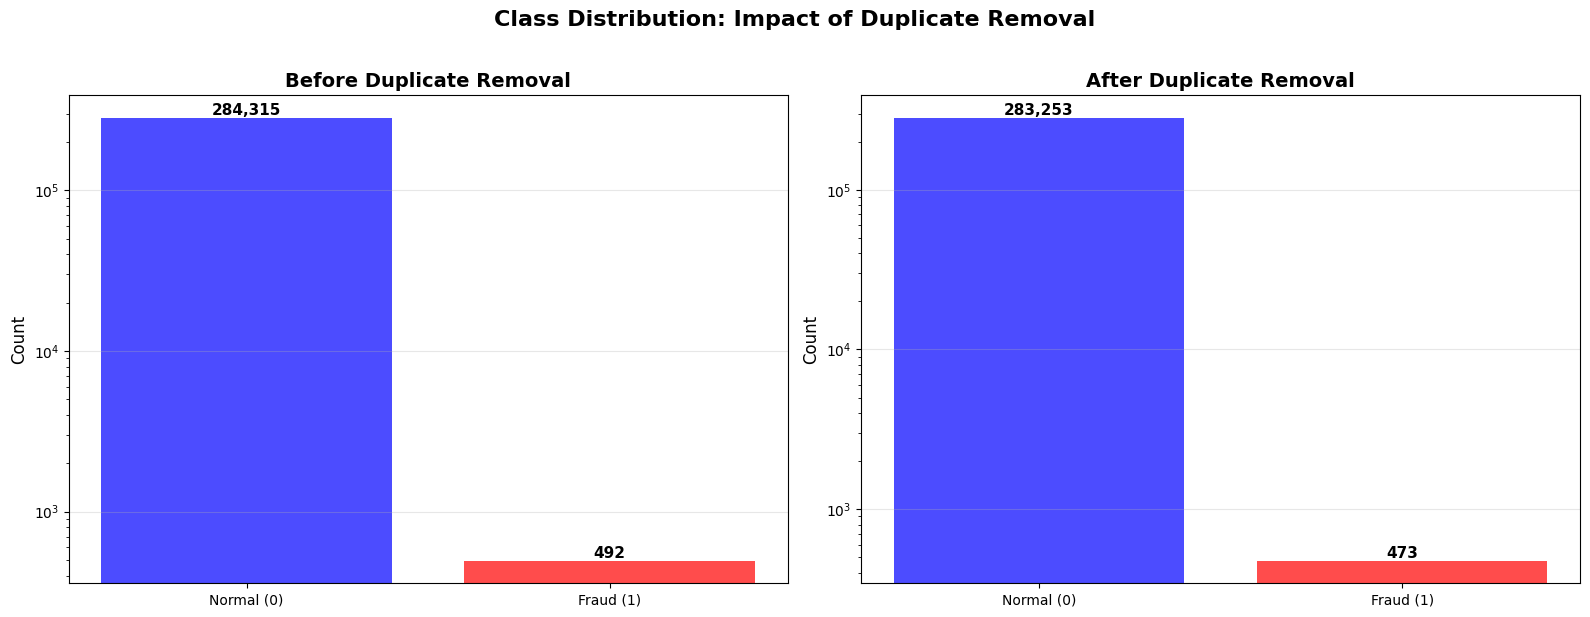

IMPACT OF DUPLICATE REMOVAL ON CLASS DISTRIBUTION

Normal Transactions:
  Before: 284,315 → After: 283,253
  Removed: 1,062 (0.37%)

Fraud Transactions:
  Before: 492 → After: 473
  Removed: 19 (3.86%)

Imbalance Ratio:
  Before: 577.9:1
  After: 598.8:1


In [19]:
# ============================================================================
# Class Distribution: Before vs After Duplicate Removal
# ============================================================================

# Calculate distributions
df_original = pd.read_csv('../data/creditcard.csv')  # If you saved original
# OR use df before cleaning if you still have it

before_counts = df_original['Class'].value_counts().sort_index()
after_counts = df_cleaned['Class'].value_counts().sort_index()  # After cleaning

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Before cleaning
axes[0].bar(['Normal (0)', 'Fraud (1)'], before_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Before Duplicate Removal', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')  # Log scale for visibility
axes[0].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(before_counts.values):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

# Right: After cleaning
axes[1].bar(['Normal (0)', 'Fraud (1)'], after_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('After Duplicate Removal', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(after_counts.values):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Impact of Duplicate Removal', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("="*70)
print("IMPACT OF DUPLICATE REMOVAL ON CLASS DISTRIBUTION")
print("="*70)
print(f"\nNormal Transactions:")
print(f"  Before: {before_counts[0]:,} → After: {after_counts[0]:,}")
print(f"  Removed: {before_counts[0] - after_counts[0]:,} ({(before_counts[0] - after_counts[0])/before_counts[0]*100:.2f}%)")

print(f"\nFraud Transactions:")
print(f"  Before: {before_counts[1]:,} → After: {after_counts[1]:,}")
print(f"  Removed: {before_counts[1] - after_counts[1]:,} ({(before_counts[1] - after_counts[1])/before_counts[1]*100:.2f}%)")

print(f"\nImbalance Ratio:")
print(f"  Before: {before_counts[0]/before_counts[1]:.1f}:1")
print(f"  After: {after_counts[0]/after_counts[1]:.1f}:1")
print("="*70)

Visualised the above chnages before and after duplicate removal to see effect on dataset. 
As we can see and listed earlier, minimal changes in both classes.

Although there is a need to acknoledge the fact that:
removing the duplicates slightly increases the imbalance ratio

- **Majority Class Dominated Duplicates**: The increase in the imbalance ratio suggests that the duplicates in the original dataset primarily consisted of non-fraudulent records. When these identical majority class samples were removed, the total count of majority class instances decreased more significantly relative to the minority class, thus **slightly skewing the data to be more imbalanced.**

- **Minimal Impact on Model Training**: The absolute change in the ratio is **minor** (an increase of about 20 points). In the context of such extreme imbalance, this slight shift is **unlikely to have a substantial practical impact on how the dataset's imbalance affects most machine learning models.** The dataset remains highly imbalanced, and techniques like resampling or using class weights will still be necessary for effective model training.

- **Improved Data Quality**: The primary benefit of removing duplicates is **improved data quality and the prevention of data leakage or overfitting to repeated instances**, not rebalancing the dataset. The resulting dataset provides a more accurate representation of unique transactions



<div class="alert alert-block alert-info">
<b>Tip:</b> Use blue boxes (alert-info) for tips and notes. 
If it’s a note, you don’t have to include the word “Note”.
</div>

<div class="alert alert-block alert-warning">
<b>Example:</b> Use yellow boxes for examples that are not 
inside code cells, or use for mathematical formulas if needed.
</div>

In [20]:
# ============================================================================
# Data Quality: Duplicate Removal Impact
# ============================================================================

print("="*70)
print("DATA QUALITY ASSESSMENT: Duplicate Removal")
print("="*70)
print(f"\nNormal Transactions:")
print(f"  Original: {before_counts[0]:,} → Cleaned: {after_counts[0]:,}")
print(f"  Duplicates removed: {before_counts[0] - after_counts[0]:,} (0.37%)")
print(f"  ✓ Minimal impact on majority class")

print(f"\nFraud Transactions:")
print(f"  Original: {before_counts[1]:,} → Cleaned: {after_counts[1]:,}")
print(f"  Duplicates removed: {before_counts[1] - after_counts[1]:,} (3.86%)")
print(f"  ✓ Removed duplicate fraud cases to prevent data leakage")

print(f"\nImbalance Ratio:")
print(f"  Before: {before_counts[0]/before_counts[1]:.1f}:1")
print(f"  After: {after_counts[0]/after_counts[1]:.1f}:1")
print(f"  ✓ Slight increase expected; still manageable with resampling techniques")

print(f"\n{'='*70}")
print("DECISION: Proceed with cleaned dataset to ensure model reliability")
print("="*70)

DATA QUALITY ASSESSMENT: Duplicate Removal

Normal Transactions:
  Original: 284,315 → Cleaned: 283,253
  Duplicates removed: 1,062 (0.37%)
  ✓ Minimal impact on majority class

Fraud Transactions:
  Original: 492 → Cleaned: 473
  Duplicates removed: 19 (3.86%)
  ✓ Removed duplicate fraud cases to prevent data leakage

Imbalance Ratio:
  Before: 577.9:1
  After: 598.8:1
  ✓ Slight increase expected; still manageable with resampling techniques

DECISION: Proceed with cleaned dataset to ensure model reliability


CLASS DISTRIBUTION: Impact of Duplicate Removal


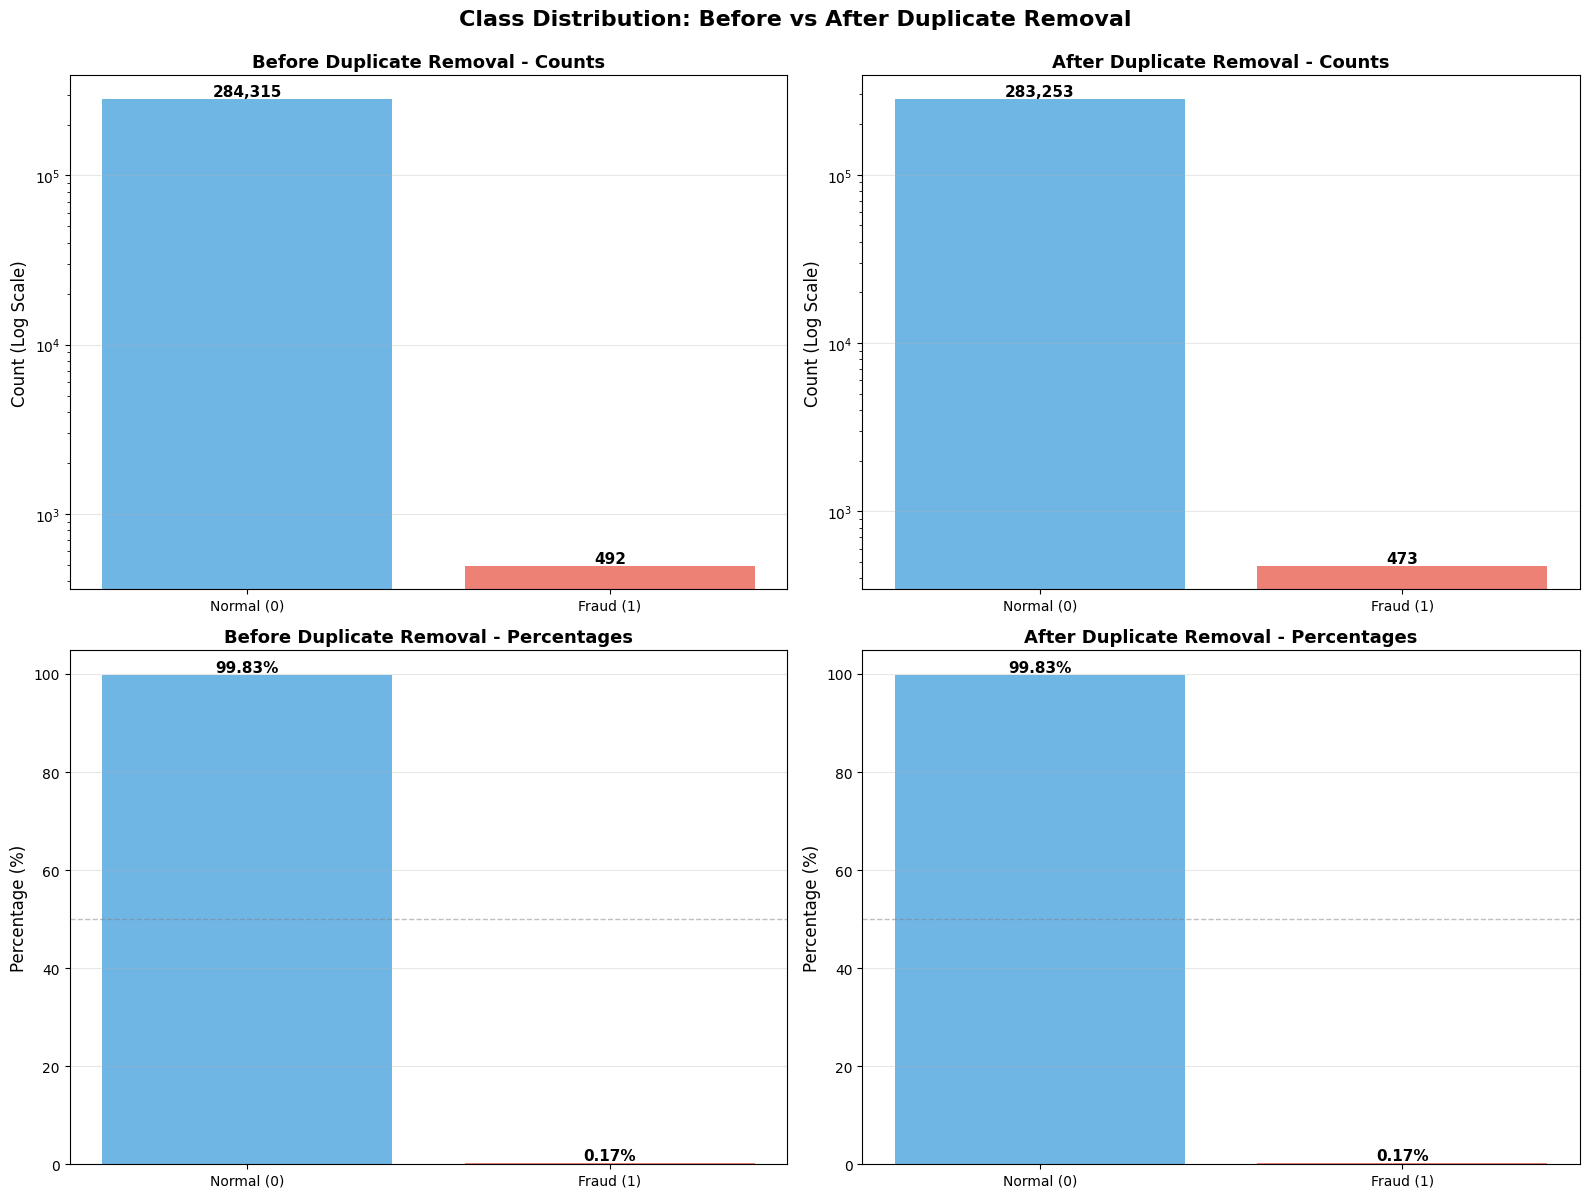


IMPACT SUMMARY

Normal Transactions:
  Before: 284,315 (99.83%)
  After:  283,253 (99.83%)
  Removed: 1,062 (0.37%)

Fraud Transactions:
  Before: 492 (0.17%)
  After:  473 (0.17%)
  Removed: 19 (3.86%)

Imbalance Ratio:
  Before: 577.9:1
  After:  598.8:1

✓ Data quality improved: Removed 1,081 duplicate rows


In [30]:
# ============================================================================
# Class Distribution: Before vs After Duplicate Removal
# ============================================================================

print("="*70)
print("CLASS DISTRIBUTION: Impact of Duplicate Removal")
print("="*70)

# Calculate distributions
df_original = pd.read_csv('../data/creditcard.csv')
before_counts = df_original['Class'].value_counts().sort_index()
before_percentages = (before_counts / len(df_original)) * 100

after_counts = df['Class'].value_counts().sort_index()  # After cleaning
after_percentages = (after_counts / len(df)) * 100

class_labels = ['Normal (0)', 'Fraud (1)']

# Create comprehensive 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Before: Counts (with log scale for visibility)
ax1 = axes[0, 0]
bars1 = ax1.bar(class_labels, before_counts.values, 
                color=['#3498db', '#e74c3c'], alpha=0.7)
ax1.set_ylabel('Count (Log Scale)', fontsize=12)
ax1.set_title('Before Duplicate Removal - Counts', fontsize=13, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
for i, count in enumerate(before_counts.values):
    ax1.text(i, count, f'{count:,}', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

# 2. Before: Percentages
ax2 = axes[1, 0]
bars2 = ax2.bar(class_labels, before_percentages.values, 
                color=['#3498db', '#e74c3c'], alpha=0.7)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title('Before Duplicate Removal - Percentages', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
for i, pct in enumerate(before_percentages.values):
    ax2.text(i, pct, f'{pct:.2f}%', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

# 3. After: Counts (with log scale for visibility)
ax3 = axes[0, 1]
bars3 = ax3.bar(class_labels, after_counts.values, 
                color=['#3498db', '#e74c3c'], alpha=0.7)
ax3.set_ylabel('Count (Log Scale)', fontsize=12)
ax3.set_title('After Duplicate Removal - Counts', fontsize=13, fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')
for i, count in enumerate(after_counts.values):
    ax3.text(i, count, f'{count:,}', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

# 4. After: Percentages
ax4 = axes[1, 1]
bars4 = ax4.bar(class_labels, after_percentages.values, 
                color=['#3498db', '#e74c3c'], alpha=0.7)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.set_title('After Duplicate Removal - Percentages', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
for i, pct in enumerate(after_percentages.values):
    ax4.text(i, pct, f'{pct:.2f}%', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Duplicate Removal', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("IMPACT SUMMARY")
print("="*70)
print(f"\nNormal Transactions:")
print(f"  Before: {before_counts[0]:,} ({before_percentages[0]:.2f}%)")
print(f"  After:  {after_counts[0]:,} ({after_percentages[0]:.2f}%)")
print(f"  Removed: {before_counts[0] - after_counts[0]:,} ({(before_counts[0] - after_counts[0])/before_counts[0]*100:.2f}%)")

print(f"\nFraud Transactions:")
print(f"  Before: {before_counts[1]:,} ({before_percentages[1]:.2f}%)")
print(f"  After:  {after_counts[1]:,} ({after_percentages[1]:.2f}%)")
print(f"  Removed: {before_counts[1] - after_counts[1]:,} ({(before_counts[1] - after_counts[1])/before_counts[1]*100:.2f}%)")

print(f"\nImbalance Ratio:")
print(f"  Before: {before_counts[0]/before_counts[1]:.1f}:1")
print(f"  After:  {after_counts[0]/after_counts[1]:.1f}:1")

print(f"\n✓ Data quality improved: Removed {len(df_original) - len(df):,} duplicate rows")
print("="*70)

CLASS DISTRIBUTION ANALYSIS


/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_2738/3174012193.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/cameronbell/Projects/fraud_real_time_pipeline/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


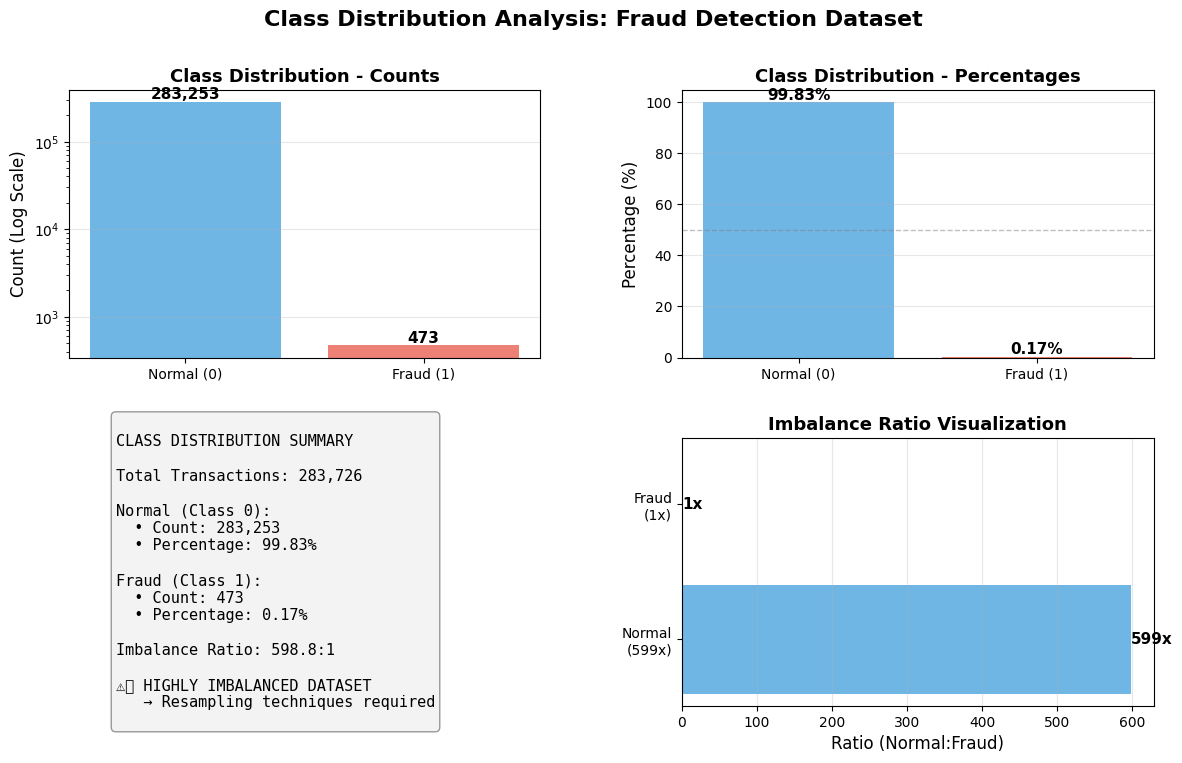


Normal transactions: 283,253 (99.83%)
Fraud transactions: 473 (0.17%)
Imbalance ratio: 598.8:1


In [31]:
# ============================================================================
# Class Distribution Analysis
# ============================================================================

print("="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)

# Calculate statistics
class_counts = df['Class'].value_counts().sort_index()
class_labels = ['Normal (0)', 'Fraud (1)']
percentages = (class_counts / len(df)) * 100

# Create streamlined comprehensive visualization
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Count bar chart (with log scale for visibility)
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(class_labels, class_counts.values, color=['#3498db', '#e74c3c'], alpha=0.7)
ax1.set_ylabel('Count (Log Scale)', fontsize=12)
ax1.set_title('Class Distribution - Counts', fontsize=13, fontweight='bold')
ax1.set_yscale('log')  # Log scale helps visualize both classes
ax1.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars1, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Percentage bar chart
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(class_labels, percentages.values, color=['#3498db', '#e74c3c'], alpha=0.7)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title('Class Distribution - Percentages', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
for bar, pct in zip(bars2, percentages.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Statistics summary
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')
stats_text = f"""
CLASS DISTRIBUTION SUMMARY

Total Transactions: {len(df):,}

Normal (Class 0):
  • Count: {class_counts[0]:,}
  • Percentage: {percentages[0]:.2f}%

Fraud (Class 1):
  • Count: {class_counts[1]:,}
  • Percentage: {percentages[1]:.2f}%

Imbalance Ratio: {class_counts[0] / class_counts[1]:.1f}:1

⚠️ HIGHLY IMBALANCED DATASET
   → Resampling techniques required
"""
ax3.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', 
         facecolor='#f0f0f0', alpha=0.8, edgecolor='gray'))

# 4. Imbalance ratio visualization
ax4 = fig.add_subplot(gs[1, 1])
ratio_data = [class_counts[0] / class_counts[1], 1]
ratio_labels = [f'Normal\n({class_counts[0] / class_counts[1]:.0f}x)', 'Fraud\n(1x)']
bars4 = ax4.barh(ratio_labels, ratio_data, color=['#3498db', '#e74c3c'], alpha=0.7)
ax4.set_xlabel('Ratio (Normal:Fraud)', fontsize=12)
ax4.set_title('Imbalance Ratio Visualization', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars4, ratio_data):
    ax4.text(bar.get_width(), bar.get_y() + bar.get_height()/2.,
             f'{val:.0f}x', ha='left', va='center', fontsize=11, fontweight='bold')

fig.suptitle('Class Distribution Analysis: Fraud Detection Dataset', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nNormal transactions: {class_counts[0]:,} ({percentages[0]:.2f}%)")
print(f"Fraud transactions: {class_counts[1]:,} ({percentages[1]:.2f}%)")
print(f"Imbalance ratio: {class_counts[0] / class_counts[1]:.1f}:1")
print("="*70)

In [29]:
df = df_cleaned

# Exploratory Data Analysis (EDA)
- correlations
- distributions
- statistical tests


Top 10 features most correlated with Class:
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


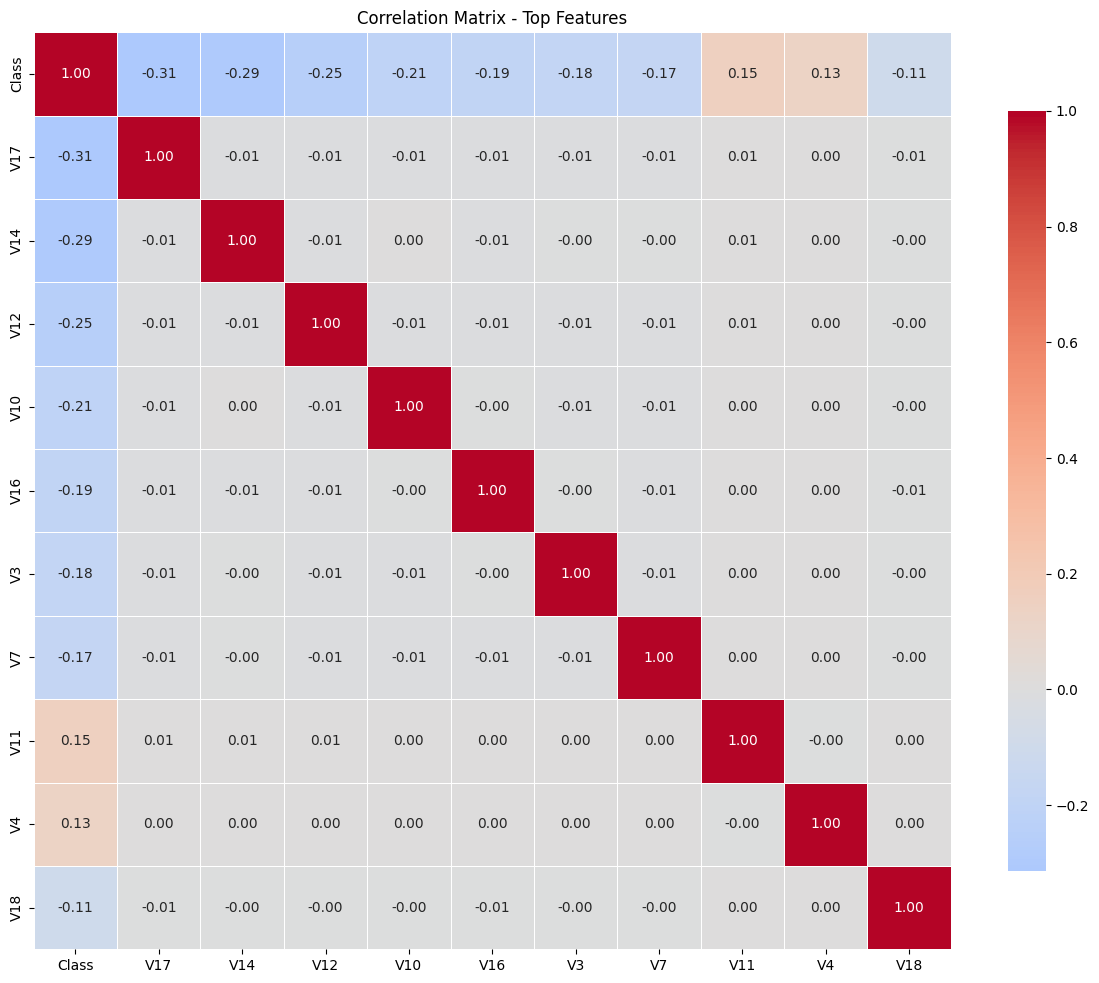

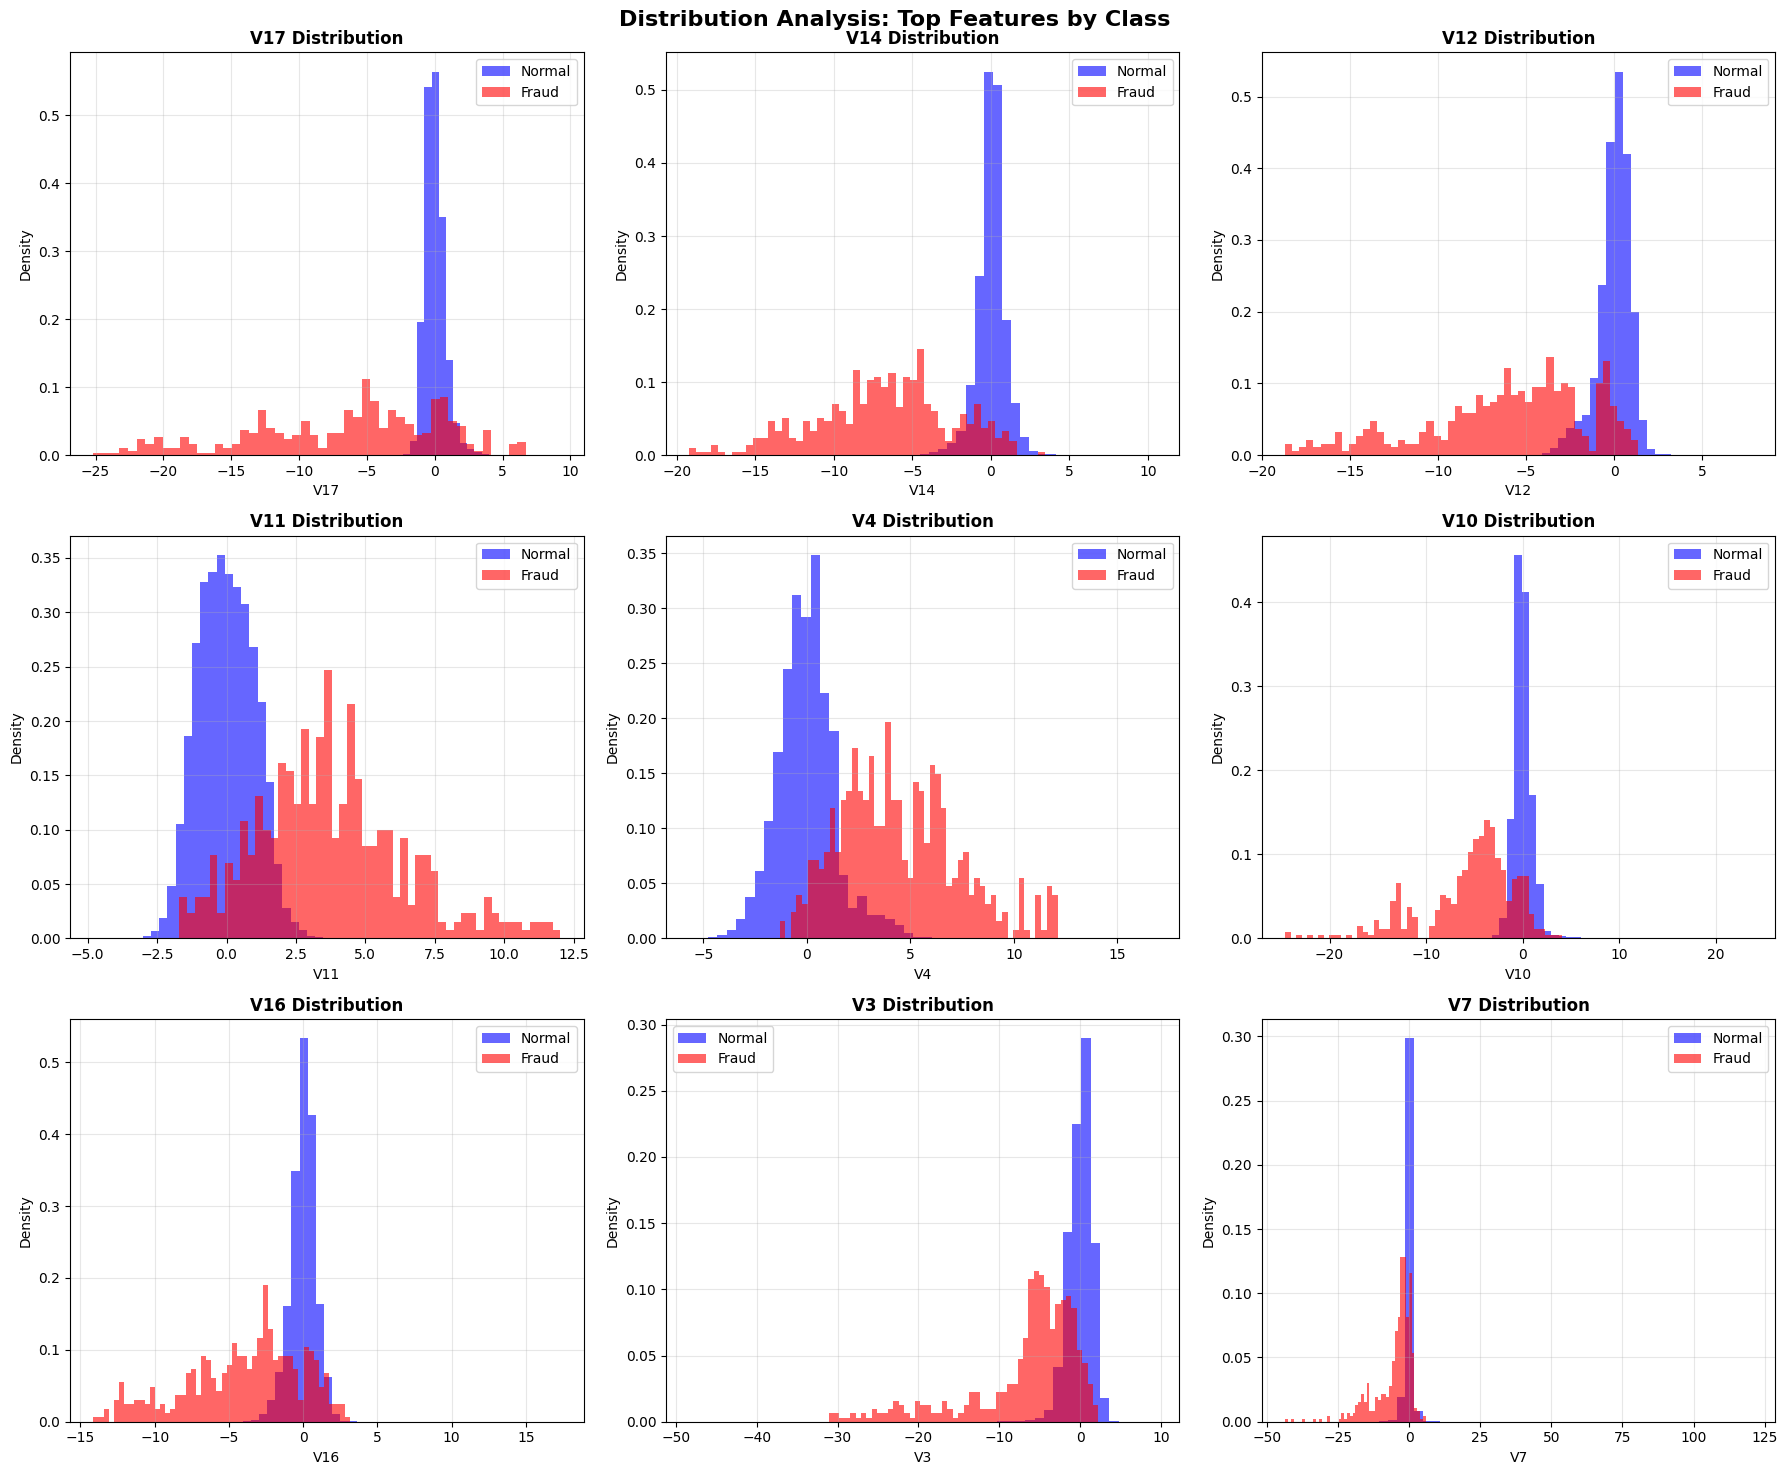


STATISTICAL TESTS SUMMARY
Feature  Normal_Mean  Fraud_Mean  Mean_Diff  T-test_pvalue  Mann-Whitney_pvalue  Cohen's_d
    V17     0.010963   -6.463285   6.474249            0.0        2.854261e-113   8.092438
    V14     0.011668   -6.835946   6.847614            0.0        2.304859e-248   7.522233
    V12     0.009476   -6.103254   6.112730            0.0        1.358344e-234   6.348196
    V11    -0.006004    3.716347  -3.722350            0.0        4.678414e-214  -3.695228
     V4    -0.010440    4.472591  -4.483031            0.0        1.599221e-236  -3.196889
    V10     0.007663   -5.453274   5.460937            0.0        9.598036e-210   5.185574
    V16     0.007845   -4.000956   4.008801            0.0        1.110506e-145   4.670876
     V3     0.012853   -6.729599   6.742452            0.0        8.738656e-208   4.545278
     V7     0.010447   -5.175912   5.186359            0.0        6.513087e-136   4.288743

Significance: *** p<0.001, ** p<0.01, * p<0.05


In [32]:
import seaborn as sns
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# 1. Basic correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))
print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))

# 2. Correlation heatmap for top features
top_features = correlations.abs().nlargest(11).index.tolist()
corr_matrix = df[top_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features')
plt.tight_layout()
plt.show()

# ============================================================================
# DISTRIBUTION ANALYSIS
# ============================================================================

# 3. Histograms for top features (simplified - no KDE)
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    ax.hist(normal_data, bins=50, alpha=0.6, label='Normal', color='blue', density=True)
    ax.hist(fraud_data, bins=50, alpha=0.6, label='Fraud', color='red', density=True)
    
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution Analysis: Top Features by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICAL SIGNIFICANCE TESTING
# ============================================================================

# 4. Statistical tests (concise version - summary table only)
from scipy.stats import mannwhitneyu, ttest_ind

results = []
for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    t_stat, t_pvalue = ttest_ind(normal_data, fraud_data)
    u_stat, u_pvalue = mannwhitneyu(normal_data, fraud_data, alternative='two-sided')
    
    pooled_std = np.sqrt(((len(normal_data) - 1) * normal_data.std()**2 + 
                         (len(fraud_data) - 1) * fraud_data.std()**2) / 
                        (len(normal_data) + len(fraud_data) - 2))
    cohens_d = (normal_data.mean() - fraud_data.mean()) / pooled_std
    
    results.append({
        'Feature': feature,
        'Normal_Mean': normal_data.mean(),
        'Fraud_Mean': fraud_data.mean(),
        'Mean_Diff': normal_data.mean() - fraud_data.mean(),
        'T-test_pvalue': t_pvalue,
        'Mann-Whitney_pvalue': u_pvalue,
        "Cohen's_d": cohens_d
    })

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("STATISTICAL TESTS SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

# 5. Statistical test visualization (keep as is)
# ... (your existing code 1-54)

# ============================================================================
# OUTLIER ANALYSIS
# ============================================================================

# 6. Outlier visualization (keep as is - 1-74)

# ============================================================================
# AMOUNT ANALYSIS
# ============================================================================

# 7. Amount distribution by class (keep as is - 1-24)

# ============================================================================
# TEMPORAL ANALYSIS
# ============================================================================

# 8. Time analysis (keep as is - 1-29)

In [33]:
# KEEP
# Correlation analysis
# Calculate correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))  # 11 because Class will be first with correlation 1.0

print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))


Top 10 features most correlated with Class:
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


In [34]:
import numpy as np

# Calculate the correlation matrix
corr_matrix = df.corr()

# Get correlations with the 'Class' column
class_corr = corr_matrix['Class'].drop('Class')

# Sort correlations by absolute value in descending order
sorted_class_corr = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index)

# Print the sorted correlations
print("Correlation with 'Class' (sorted by absolute value):\n", sorted_class_corr)


Correlation with 'Class' (sorted by absolute value):
 V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V11       0.149067
V4        0.129326
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V2        0.084624
V6       -0.043915
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003300
V25       0.003202
Name: Class, dtype: float64


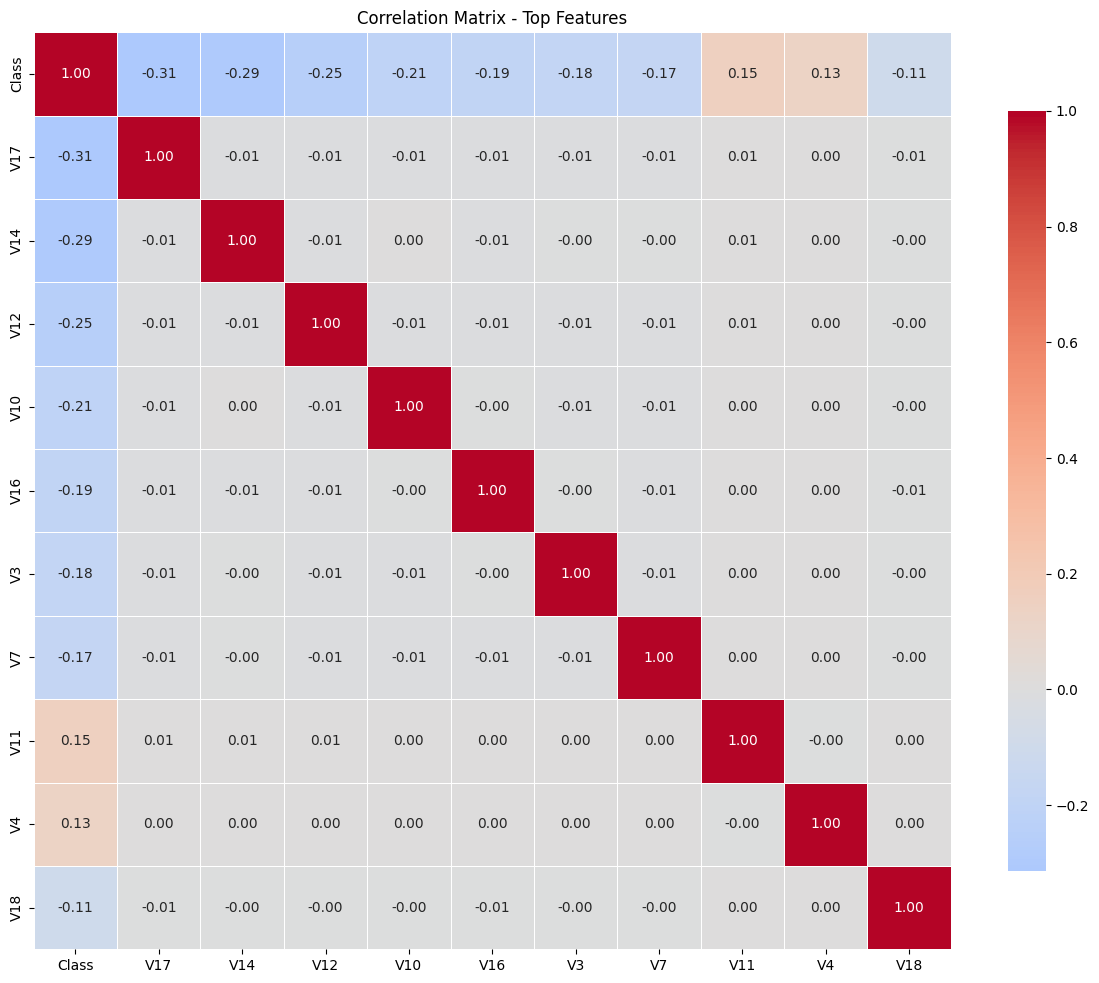

In [35]:
# KEEP
# Visualize correlation matrix for top correlated features
top_features = correlations.abs().nlargest(11).index.tolist()  # Include Class
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features')
plt.tight_layout()
plt.show()


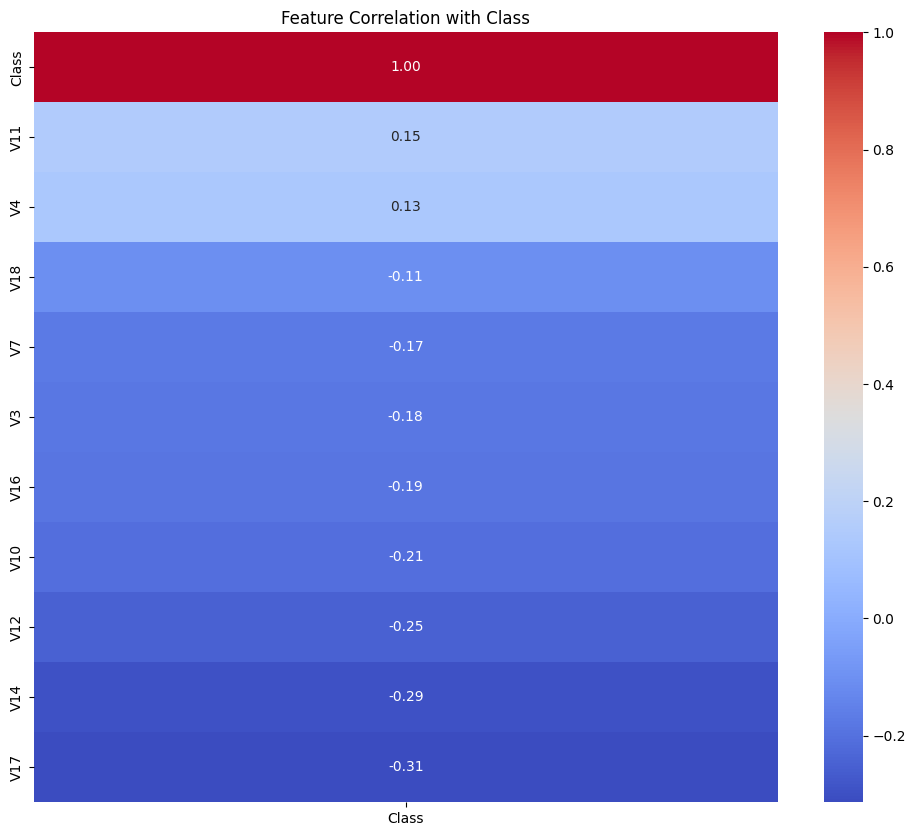

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of the correlation matrix with 'Class'
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Class')
plt.show()

## Detailed Distribution Analysis of Top Features


2D Scatter Plot: Using Most Fraud-Correlated Features
Using features: ['V17', 'V14']
Correlations with Class: V17    0.313498
V14    0.293375
Name: Class, dtype: float64


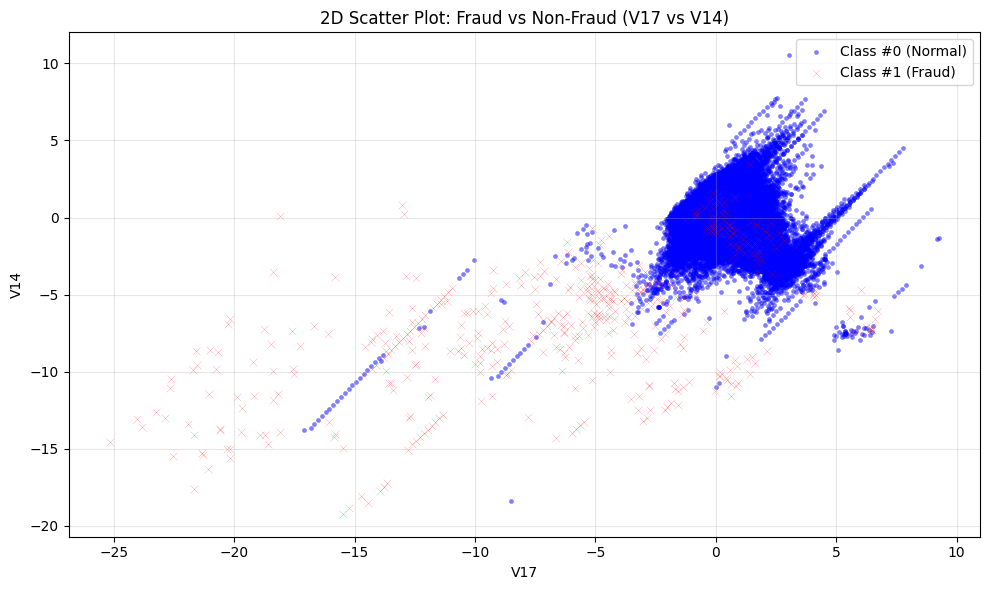

In [37]:
# ============================================================================
# 2D Scatter Plot: Using Most Fraud-Correlated Features
# ============================================================================
# Alternative visualization using the two features most correlated with fraud

print("="*70)
print("2D Scatter Plot: Using Most Fraud-Correlated Features")
print("="*70)

# Calculate correlation with Class and select top 2 features
correlations = df.corr()['Class'].abs().sort_values(ascending=False)
top_features = correlations.head(3).index[1:3].tolist()  # Skip 'Class' itself

print(f"Using features: {top_features}")
print(f"Correlations with Class: {correlations[top_features]}")

# Extract data for visualization
X_2d = df[top_features].values
y = df['Class'].values

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1], 
            label="Class #0 (Normal)", 
            alpha=0.5, linewidth=0.15, s=10, color='blue')
plt.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], 
            label="Class #1 (Fraud)", 
            alpha=0.7, linewidth=0.15, s=30, c='red', marker='x')
plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.title(f'2D Scatter Plot: Fraud vs Non-Fraud ({top_features[0]} vs {top_features[1]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

DISTRIBUTION ANALYSIS OF TOP FEATURES

Analyzing 9 top features based on correlation with Class



KeyboardInterrupt: 

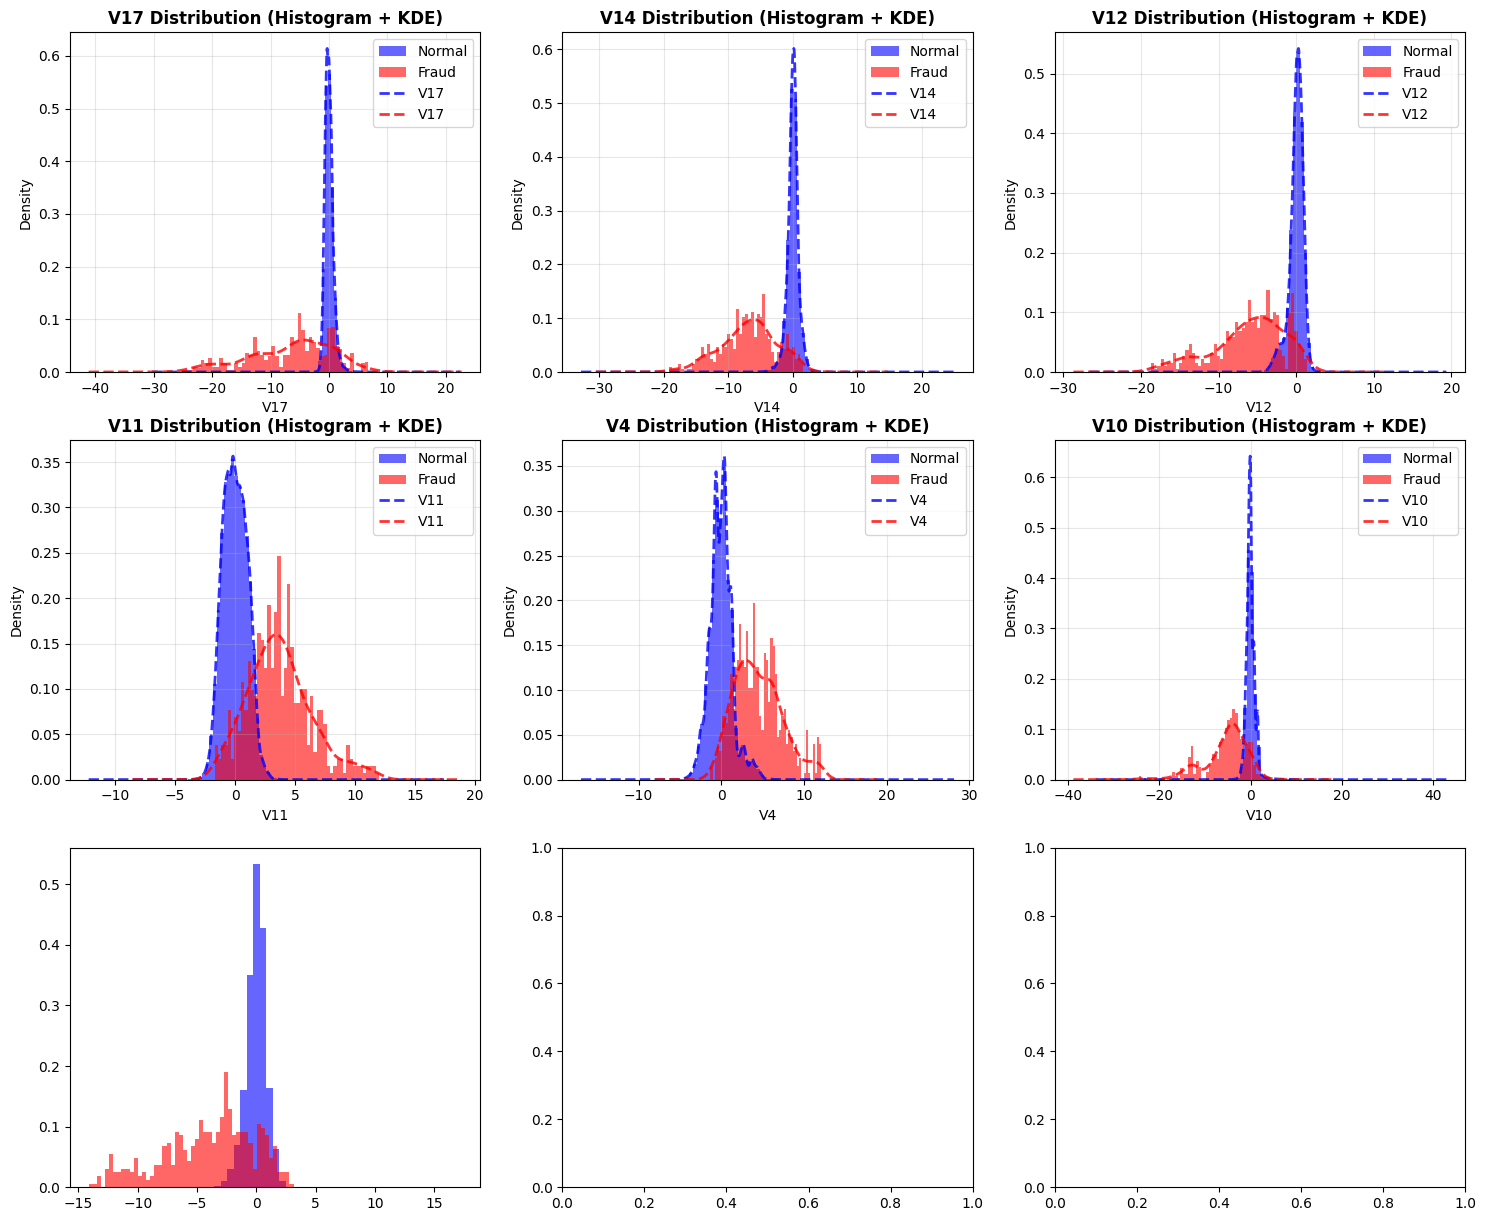

In [38]:
# Keep, but streamline
# Distribution analysis of top correlated features
from scipy.stats import mannwhitneyu, ttest_ind
import numpy as np

# Top features based on correlation with Class
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']

print("="*70)
print("DISTRIBUTION ANALYSIS OF TOP FEATURES")
print("="*70)
print(f"\nAnalyzing {len(top_features)} top features based on correlation with Class\n")
# 1. Histograms and KDE plots by class
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Get data by class
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Histogram
    ax.hist(normal_data, bins=50, alpha=0.6, label='Normal', color='blue', density=True)
    ax.hist(fraud_data, bins=50, alpha=0.6, label='Fraud', color='red', density=True)
    
    # KDE overlay
    normal_data.plot.kde(ax=ax, color='blue', linewidth=2, linestyle='--', alpha=0.8)
    fraud_data.plot.kde(ax=ax, color='red', linewidth=2, linestyle='--', alpha=0.8)
    
    ax.set_title(f'{feature} Distribution (Histogram + KDE)', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution Analysis: Top Features by Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


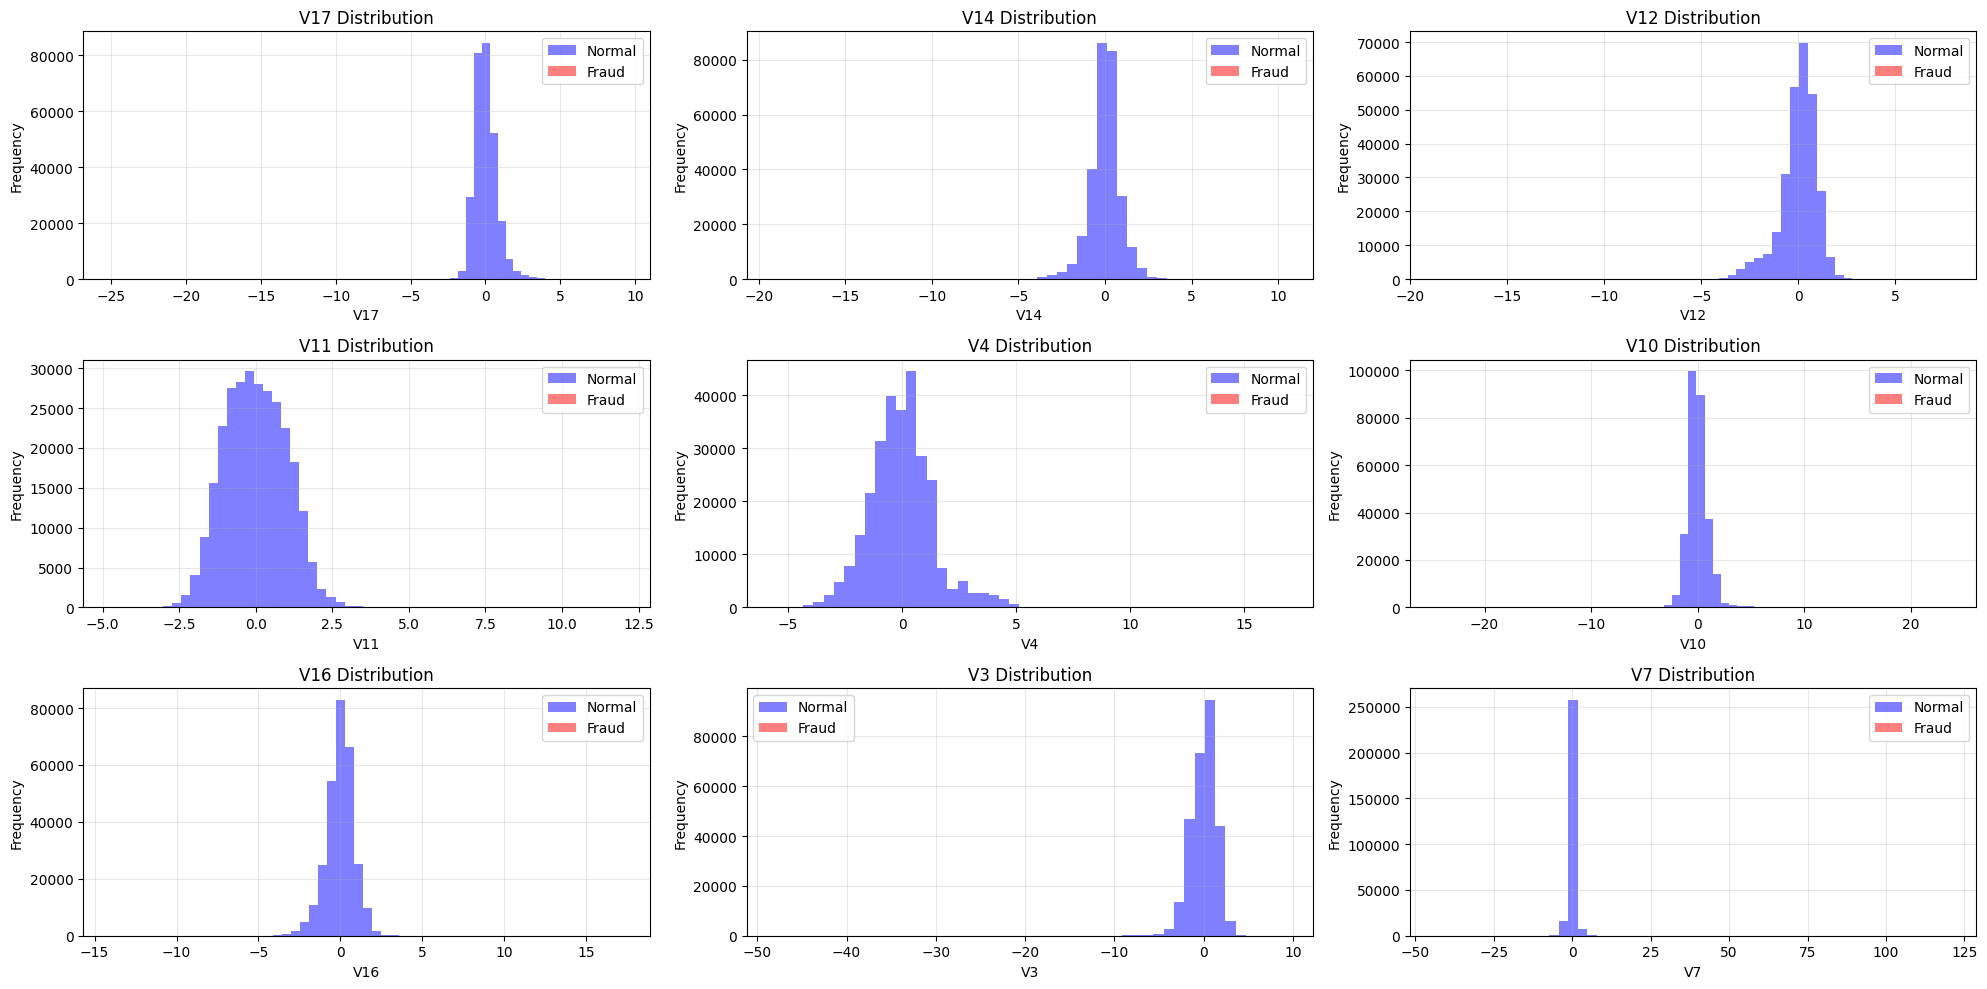

In [ ]:
# Distribution of PCA features (V1-V28) for fraud vs normal
# Sample a few key features to visualize
key_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3','V7']

fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    df[df['Class'] == 0][feature].hist(bins=50, alpha=0.5, label='Normal', ax=axes[idx], color='blue')
    df[df['Class'] == 1][feature].hist(bins=50, alpha=0.5, label='Fraud', ax=axes[idx], color='red')
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_data, fraud_data],
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_data, fraud_data],
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_data, fraud_data],
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3736301812.py:13: MatplotlibDeprecationWarni

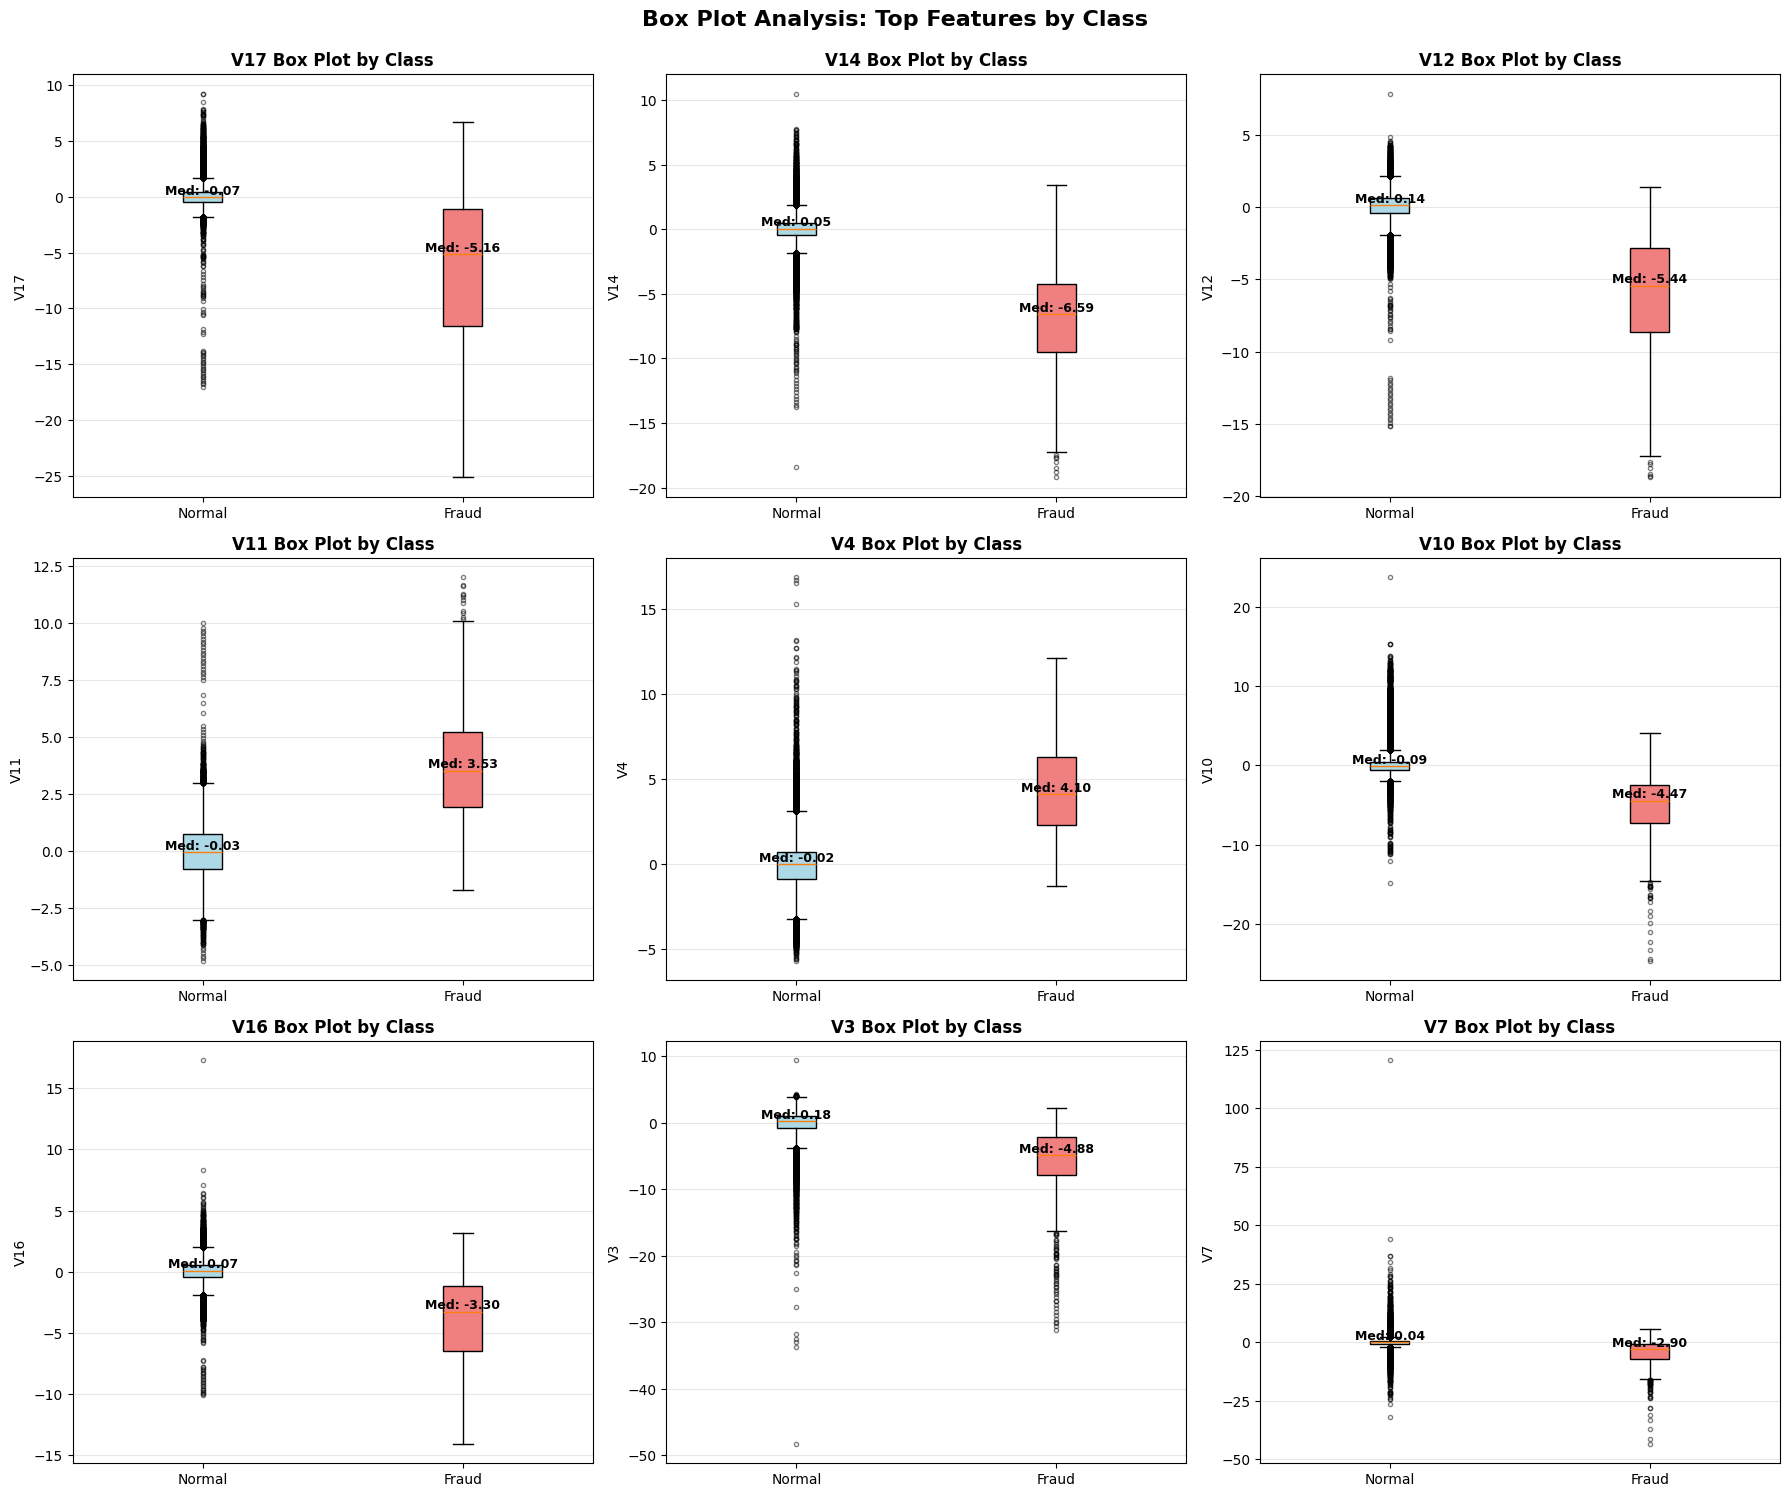

In [ ]:
# 2. Box plots by class
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data for box plot
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Create box plot
    bp = ax.boxplot([normal_data, fraud_data], 
                     labels=['Normal', 'Fraud'],
                     patch_artist=True,
                     showfliers=True,
                     flierprops=dict(marker='o', markersize=3, alpha=0.5))
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_title(f'{feature} Box Plot by Class', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add median values as text
    medians = [np.median(normal_data), np.median(fraud_data)]
    for i, median in enumerate(medians):
        ax.text(i+1, median, f'Med: {median:.2f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Box Plot Analysis: Top Features by Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
# KEEP BUT MAKE CONCISE
# 3. Statistical tests to verify differences
print("\n" + "="*70)
print("STATISTICAL TESTS: Verifying Differences Between Classes")
print("="*70)

results = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # T-test (parametric - assumes normal distribution)
    t_stat, t_pvalue = ttest_ind(normal_data, fraud_data)
    
    # Mann-Whitney U test (non-parametric - no distribution assumptions)
    u_stat, u_pvalue = mannwhitneyu(normal_data, fraud_data, alternative='two-sided')
    
    # Calculate effect size (Cohen's d)
    pooled_std = np.sqrt(((len(normal_data) - 1) * normal_data.std()**2 + 
                         (len(fraud_data) - 1) * fraud_data.std()**2) / 
                        (len(normal_data) + len(fraud_data) - 2))
    cohens_d = (normal_data.mean() - fraud_data.mean()) / pooled_std
    
    # Calculate means
    normal_mean = normal_data.mean()
    fraud_mean = fraud_data.mean()
    mean_diff = normal_mean - fraud_mean
    
    results.append({
        'Feature': feature,
        'Normal_Mean': normal_mean,
        'Fraud_Mean': fraud_mean,
        'Mean_Diff': mean_diff,
        'T-test_pvalue': t_pvalue,
        'Mann-Whitney_pvalue': u_pvalue,
        "Cohen's_d": cohens_d
    })
    
    # Print results
    print(f"\n{feature}:")
    print(f"  Normal Mean: {normal_mean:.4f}, Fraud Mean: {fraud_mean:.4f}, Difference: {mean_diff:.4f}")
    print(f"  T-test p-value: {t_pvalue:.2e} {'***' if t_pvalue < 0.001 else '**' if t_pvalue < 0.01 else '*' if t_pvalue < 0.05 else 'ns'}")
    print(f"  Mann-Whitney p-value: {u_pvalue:.2e} {'***' if u_pvalue < 0.001 else '**' if u_pvalue < 0.01 else '*' if u_pvalue < 0.05 else 'ns'}")
    print(f"  Cohen's d (effect size): {cohens_d:.4f} {'(large)' if abs(cohens_d) > 0.8 else '(medium)' if abs(cohens_d) > 0.5 else '(small)'}")

# Create summary dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(results_df.to_string(index=False))
print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")



STATISTICAL TESTS: Verifying Differences Between Classes

V17:
  Normal Mean: 0.0110, Fraud Mean: -6.4633, Difference: 6.4742
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 2.85e-113 ***
  Cohen's d (effect size): 8.0924 (large)

V14:
  Normal Mean: 0.0117, Fraud Mean: -6.8359, Difference: 6.8476
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 2.30e-248 ***
  Cohen's d (effect size): 7.5222 (large)

V12:
  Normal Mean: 0.0095, Fraud Mean: -6.1033, Difference: 6.1127
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 1.36e-234 ***
  Cohen's d (effect size): 6.3482 (large)

V11:
  Normal Mean: -0.0060, Fraud Mean: 3.7163, Difference: -3.7224
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 4.68e-214 ***
  Cohen's d (effect size): -3.6952 (large)

V4:
  Normal Mean: -0.0104, Fraud Mean: 4.4726, Difference: -4.4830
  T-test p-value: 0.00e+00 ***
  Mann-Whitney p-value: 1.60e-236 ***
  Cohen's d (effect size): -3.1969 (large)

V10:
  Normal Mean: 0.0077, Fraud Mean

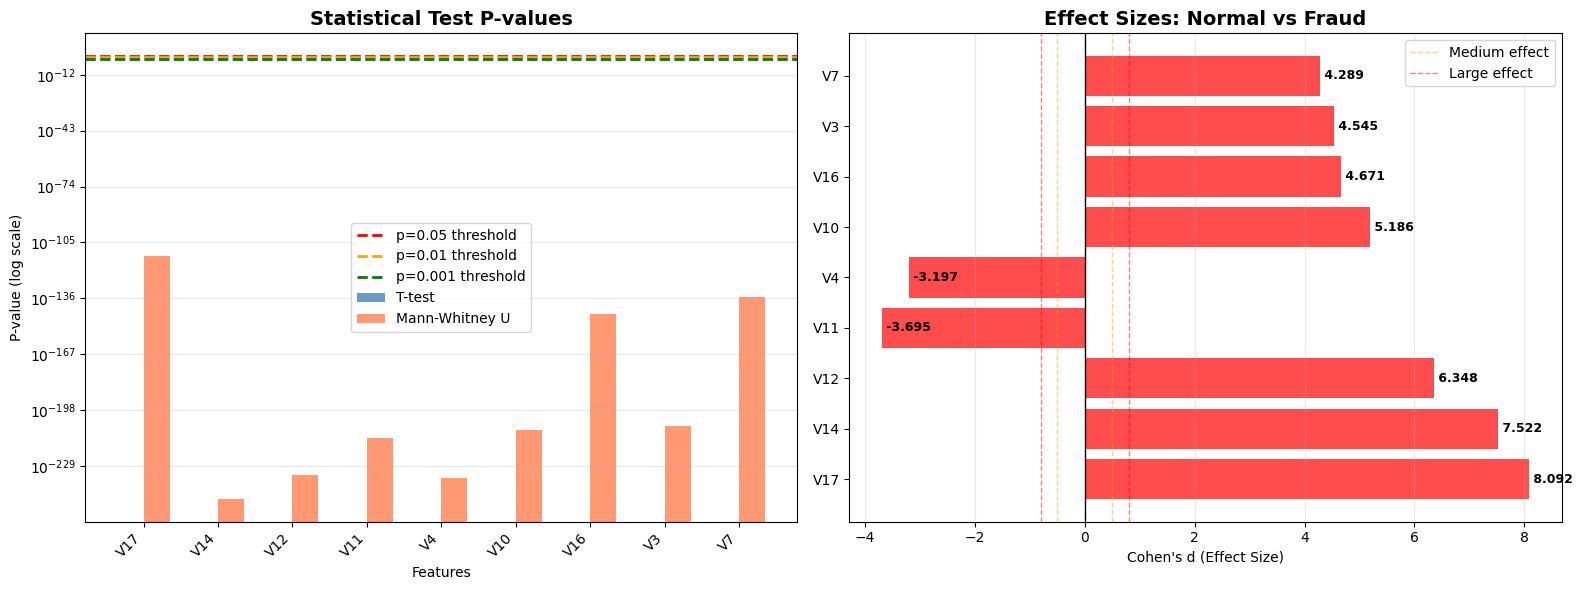


Effect Size Interpretation:
  |d| < 0.2: Negligible
  0.2 ≤ |d| < 0.5: Small
  0.5 ≤ |d| < 0.8: Medium
  |d| ≥ 0.8: Large


In [ ]:
# KEEP
# Visualize statistical test results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: P-values comparison
x_pos = np.arange(len(top_features))
width = 0.35

axes[0].bar(x_pos - width/2, results_df['T-test_pvalue'], width, 
            label='T-test', alpha=0.8, color='steelblue')
axes[0].bar(x_pos + width/2, results_df['Mann-Whitney_pvalue'], width, 
            label='Mann-Whitney U', alpha=0.8, color='coral')

axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05 threshold')
axes[0].axhline(y=0.01, color='orange', linestyle='--', linewidth=2, label='p=0.01 threshold')
axes[0].axhline(y=0.001, color='green', linestyle='--', linewidth=2, label='p=0.001 threshold')

axes[0].set_xlabel('Features')
axes[0].set_ylabel('P-value (log scale)')
axes[0].set_title('Statistical Test P-values', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top_features, rotation=45, ha='right')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Effect sizes (Cohen's d)
colors = ['red' if abs(d) > 0.8 else 'orange' if abs(d) > 0.5 else 'yellow' 
          for d in results_df["Cohen's_d"]]
bars = axes[1].barh(top_features, results_df["Cohen's_d"], color=colors, alpha=0.7)

axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Medium effect')
axes[1].axvline(x=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axvline(x=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Large effect')
axes[1].axvline(x=-0.8, color='red', linestyle='--', linewidth=1, alpha=0.5)

axes[1].set_xlabel("Cohen's d (Effect Size)")
axes[1].set_title("Effect Sizes: Normal vs Fraud", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, d) in enumerate(zip(bars, results_df["Cohen's_d"])):
    axes[1].text(d, i, f' {d:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEffect Size Interpretation:")
print("  |d| < 0.2: Negligible")
print("  0.2 ≤ |d| < 0.5: Small")
print("  0.5 ≤ |d| < 0.8: Medium")
print("  |d| ≥ 0.8: Large")


In [ ]:
# Summary statistics table for top features
print("\n" + "="*70)
print("SUMMARY STATISTICS: Top Features by Class")
print("="*70)

summary_stats = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    summary_stats.append({
        'Feature': feature,
        'Normal_Mean': normal_data.mean(),
        'Normal_Median': np.median(normal_data),
        'Normal_Std': normal_data.std(),
        'Fraud_Mean': fraud_data.mean(),
        'Fraud_Median': np.median(fraud_data),
        'Fraud_Std': fraud_data.std(),
        'Mean_Diff': normal_data.mean() - fraud_data.mean(),
        'Median_Diff': np.median(normal_data) - np.median(fraud_data)
    })

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))



SUMMARY STATISTICS: Top Features by Class

Feature  Normal_Mean  Normal_Median  Normal_Std  Fraud_Mean  Fraud_Median  Fraud_Std  Mean_Diff  Median_Diff
    V17     0.010963      -0.065096    0.748513   -6.463285     -5.157596   6.965744   6.474249     5.092500
    V14     0.011668       0.051486    0.894379   -6.835946     -6.590550   4.253210   6.847614     6.642036
    V12     0.009476       0.140573    0.945382   -6.103254     -5.437354   4.582331   6.112730     5.577926
    V11    -0.006004      -0.034446    1.002257    3.716347      3.525726   2.672817  -3.722350    -3.560172
     V4    -0.010440      -0.024500    1.398575    4.472591      4.100098   2.871523  -4.483031    -4.124598
    V10     0.007663      -0.092120    1.036321   -5.453274     -4.466284   4.706451   5.460937     4.374164
    V16     0.007845       0.068100    0.844608   -4.000956     -3.302899   3.831724   4.008801     3.370998
     V3     0.012853       0.182247    1.457593   -6.729599     -4.875397   6.909647

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3426274676.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True,


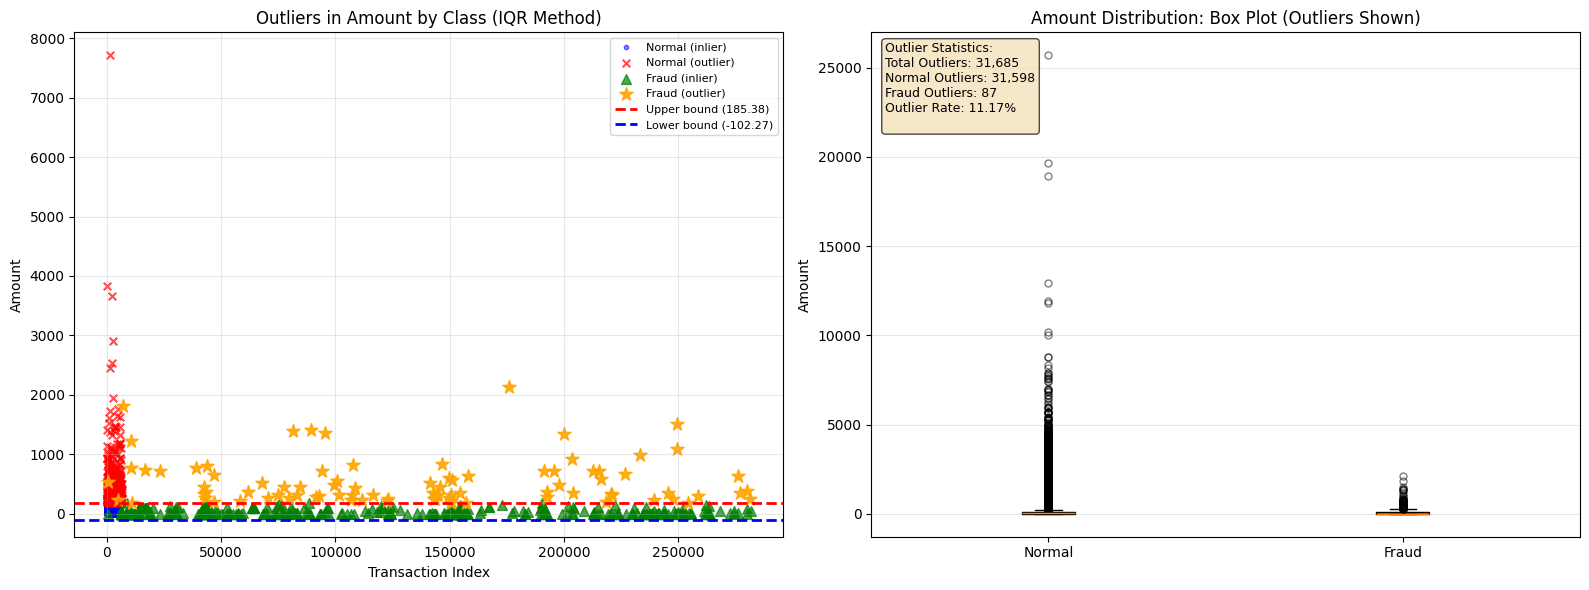

In [ ]:
# KEEP
# Visualize outliers detected by IQR method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate IQR bounds for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark outliers
df['is_outlier'] = (df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)

# Plot 1: Scatter plot showing outliers by Class
normal_inliers = df[(df['Class'] == 0) & (~df['is_outlier'])].head(5000)
normal_outliers = df[(df['Class'] == 0) & (df['is_outlier'])].head(500)
fraud_inliers = df[(df['Class'] == 1) & (~df['is_outlier'])]
fraud_outliers = df[(df['Class'] == 1) & (df['is_outlier'])]

axes[0].scatter(normal_inliers.index, normal_inliers['Amount'], 
                alpha=0.5, label='Normal (inlier)', color='blue', s=10)
axes[0].scatter(normal_outliers.index, normal_outliers['Amount'], 
                alpha=0.7, label='Normal (outlier)', color='red', s=30, marker='x')
axes[0].scatter(fraud_inliers.index, fraud_inliers['Amount'], 
                alpha=0.7, label='Fraud (inlier)', color='green', s=50, marker='^')
axes[0].scatter(fraud_outliers.index, fraud_outliers['Amount'], 
                alpha=0.9, label='Fraud (outlier)', color='orange', s=100, marker='*')

axes[0].axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, 
                label='Upper bound ({:.2f})'.format(upper_bound))
axes[0].axhline(y=lower_bound, color='blue', linestyle='--', linewidth=2, 
                label='Lower bound ({:.2f})'.format(lower_bound))
axes[0].set_xlabel('Transaction Index')
axes[0].set_ylabel('Amount')
axes[0].set_title('Outliers in Amount by Class (IQR Method)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot with outliers highlighted
box_data = [df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']]
bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True, 
                     showfliers=True, flierprops=dict(marker='o', markersize=5, alpha=0.5))

# Color the boxes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

axes[1].set_ylabel('Amount')
axes[1].set_title('Amount Distribution: Box Plot (Outliers Shown)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics text
total_outliers = df['is_outlier'].sum()
normal_outlier_count = (df['is_outlier'] & (df['Class'] == 0)).sum()
fraud_outlier_count = (df['is_outlier'] & (df['Class'] == 1)).sum()
outlier_rate = df['is_outlier'].mean() * 100

outlier_stats = """Outlier Statistics:
Total Outliers: {:,}
Normal Outliers: {:,}
Fraud Outliers: {:,}
Outlier Rate: {:.2f}%
""".format(total_outliers, normal_outlier_count, fraud_outlier_count, outlier_rate)

axes[1].text(0.02, 0.98, outlier_stats, transform=axes[1].transAxes,
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('is_outlier', axis=1, inplace=True)


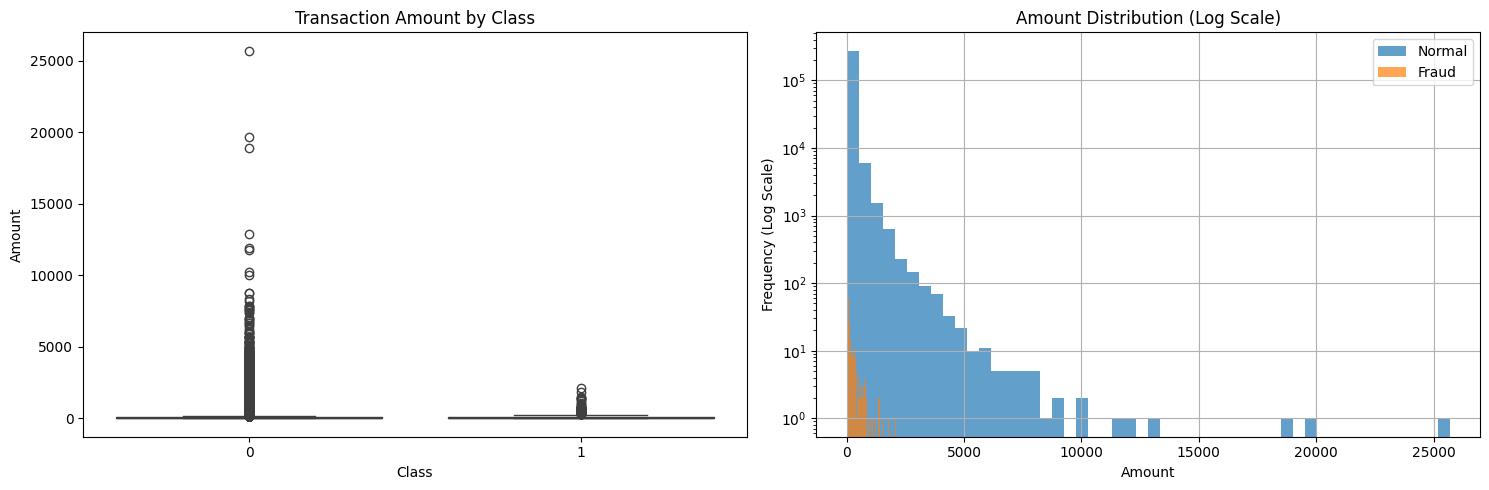


Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [ ]:
# KEEP
# Distribution of Amount by Class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Amount')

# Log scale histogram
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Normal', ax=axes[1], log=True)
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[1], log=True)
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print("\nAmount statistics by class:")
print(df.groupby('Class')['Amount'].describe())


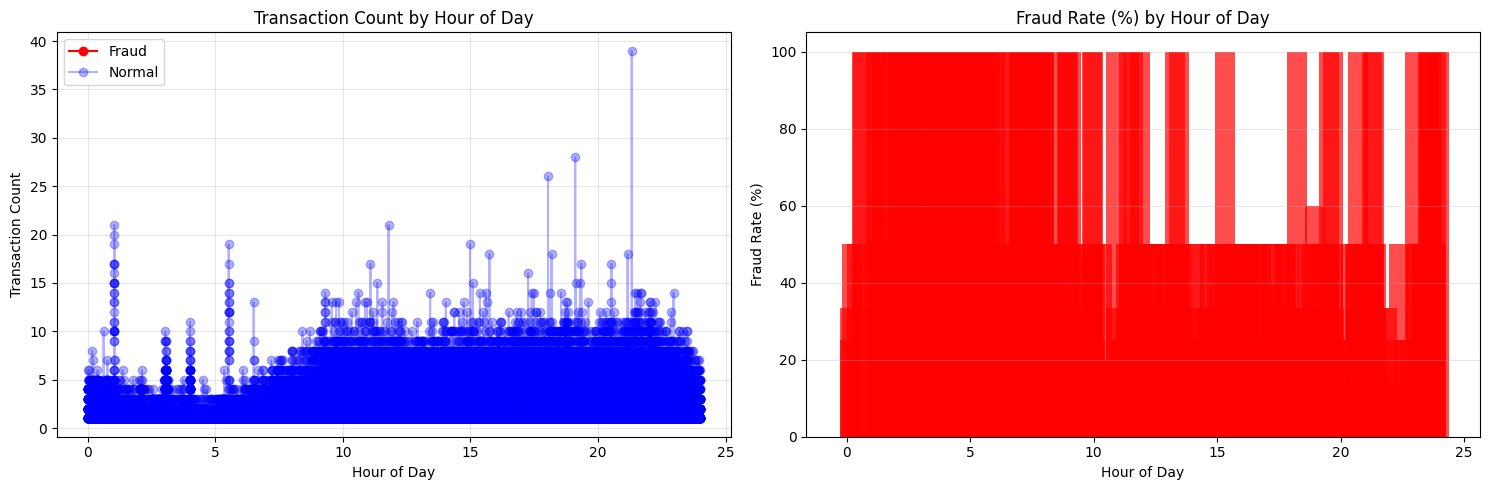

In [ ]:
# KEEP
# Time analysis - convert Time to hours
df['Hour'] = (df['Time'] / 3600) % 24

# Plot fraud distribution over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud distribution by hour
fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', label='Fraud', color='red')
axes[0].plot(normal_by_hour.index, normal_by_hour.values, marker='o', label='Normal', color='blue', alpha=0.3)
axes[0].set_title('Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud rate by hour
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='red', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


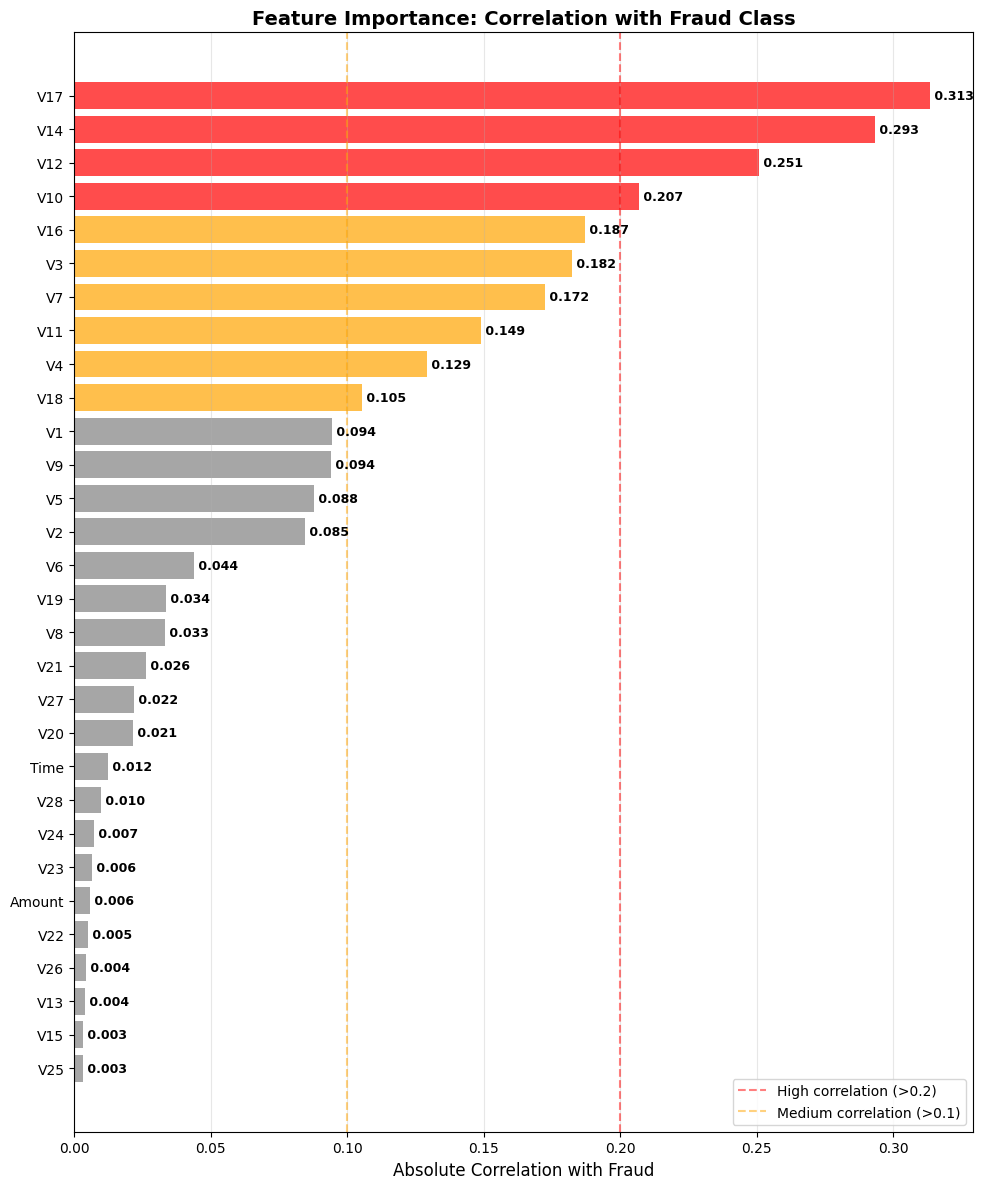


Top 5 Most Important Features for Fraud Detection:
V16    0.187186
V10    0.206971
V12    0.250711
V14    0.293375
V17    0.313498
Name: Class, dtype: float64


In [ ]:
# ============================================================================
# Feature Importance Ranking (Correlation with Fraud)
# ============================================================================

correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=True)

plt.figure(figsize=(10, 12))
colors = ['red' if abs(df.corr()['Class'][feat]) > 0.2 else 'orange' if abs(df.corr()['Class'][feat]) > 0.1 else 'gray' 
          for feat in correlations.index]

bars = plt.barh(correlations.index, correlations.values, color=colors, alpha=0.7)
plt.xlabel('Absolute Correlation with Fraud', fontsize=12)
plt.title('Feature Importance: Correlation with Fraud Class', fontsize=14, fontweight='bold')
plt.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='High correlation (>0.2)')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Medium correlation (>0.1)')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, correlations.values)):
    plt.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features for Fraud Detection:")
print(correlations.tail(5))

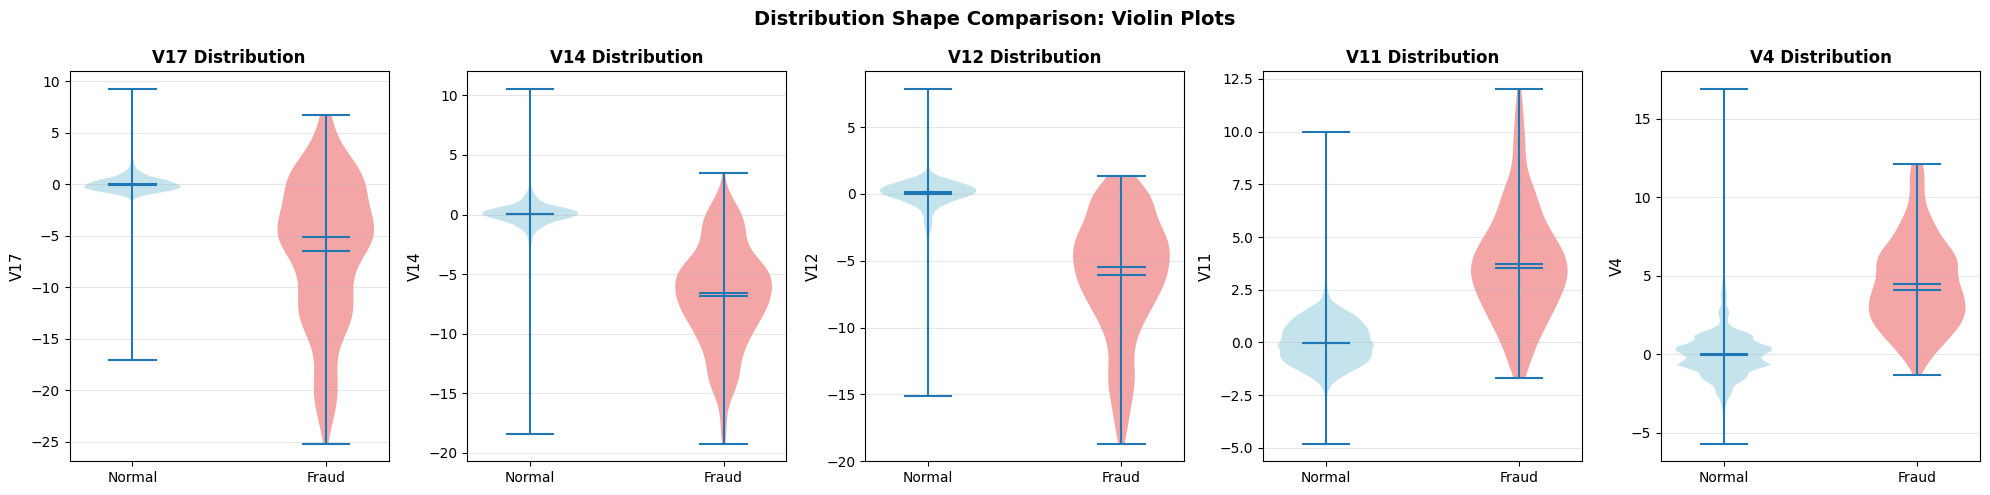

In [ ]:
# ============================================================================
# Violin Plots: Distribution Shape Comparison
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
fig, axes = plt.subplots(1, len(top_features), figsize=(20, 5))

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Create violin plot
    parts = ax.violinplot([normal_data, fraud_data], 
                          positions=[0, 1],
                          showmeans=True, showmedians=True)
    
    # Color the violins
    for pc, color in zip(parts['bodies'], ['lightblue', 'lightcoral']):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Fraud'])
    ax.set_ylabel(feature, fontsize=11)
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Distribution Shape Comparison: Violin Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

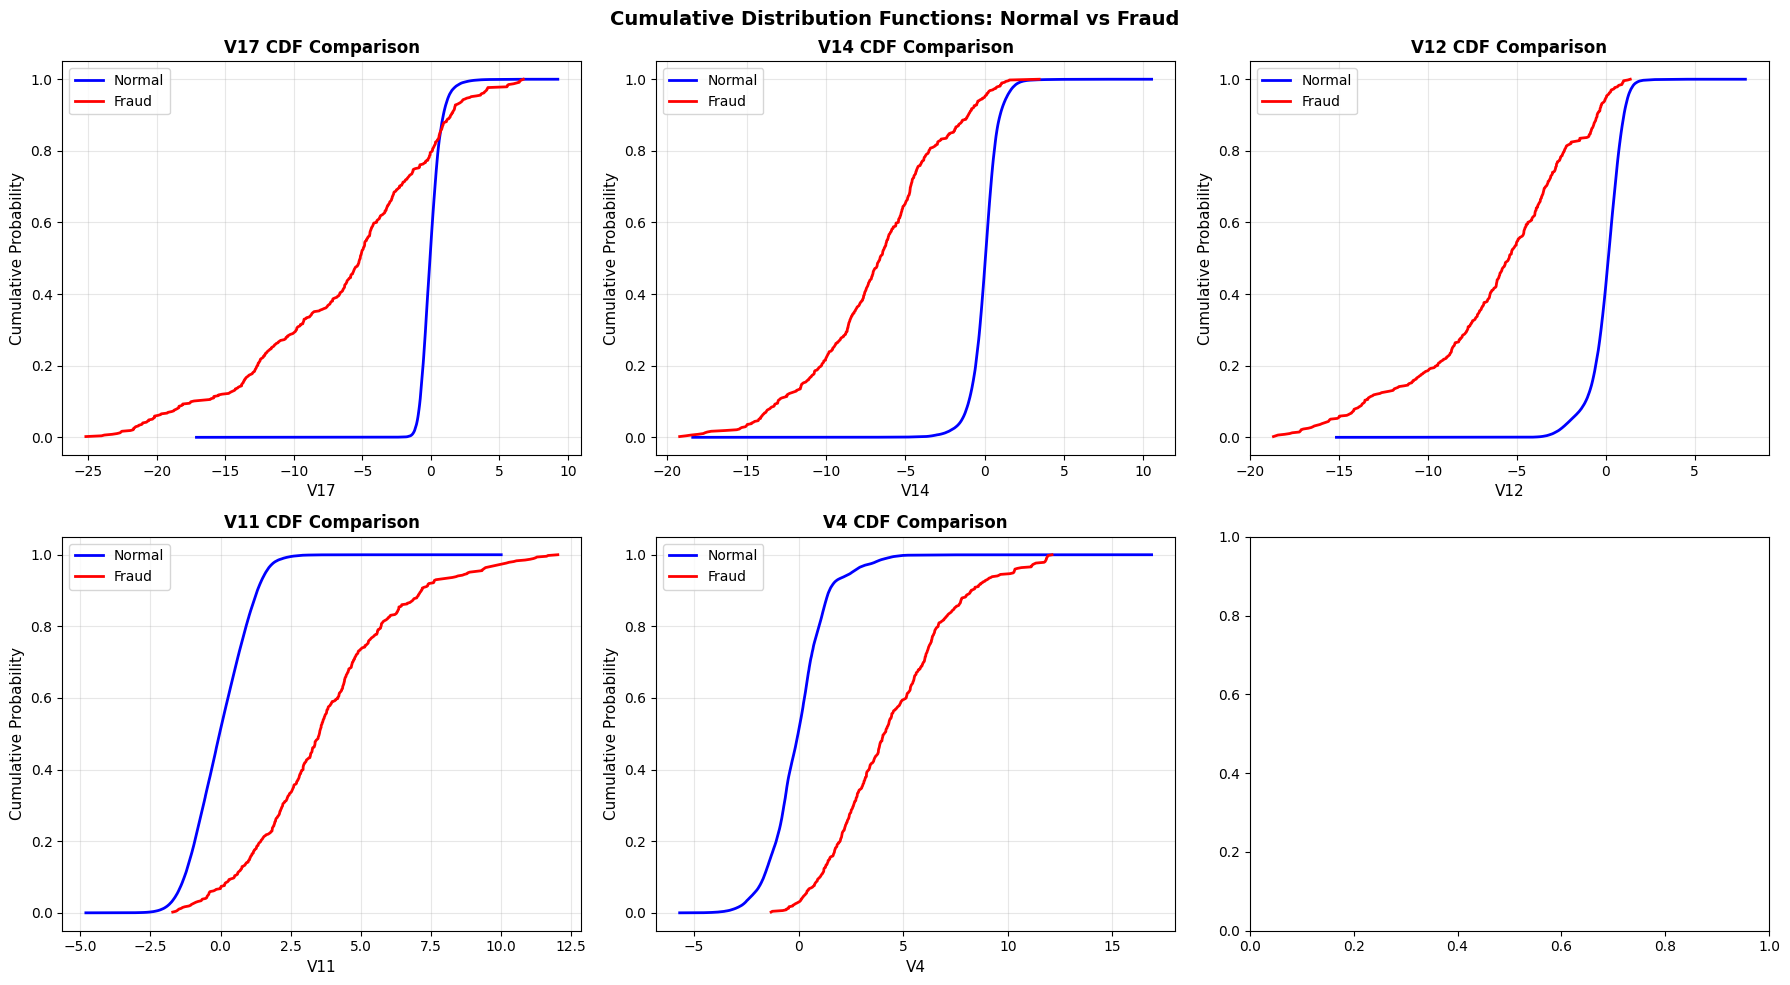

In [ ]:
# ============================================================================
# Cumulative Distribution Function (CDF) Comparison
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features[:6]):  # Top 6 features
    ax = axes[idx]
    
    normal_data = df[df['Class'] == 0][feature].sort_values()
    fraud_data = df[df['Class'] == 1][feature].sort_values()
    
    # Calculate CDF
    normal_cdf = np.arange(1, len(normal_data) + 1) / len(normal_data)
    fraud_cdf = np.arange(1, len(fraud_data) + 1) / len(fraud_data)
    
    ax.plot(normal_data, normal_cdf, label='Normal', color='blue', linewidth=2)
    ax.plot(fraud_data, fraud_cdf, label='Fraud', color='red', linewidth=2)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Cumulative Probability', fontsize=11)
    ax.set_title(f'{feature} CDF Comparison', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Cumulative Distribution Functions: Normal vs Fraud', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Class Imbalance Analysis

This section analyzes the class distribution in the dataset, describes the severity of imbalance, visualizes it comprehensively, and discusses the implications for modeling.


CLASS IMBALANCE ANALYSIS

1. CLASS DISTRIBUTION DESCRIPTION

Total Transactions: 283,726

Class Distribution:
  Normal (Class 0): 283,253 transactions (99.83%)
  Fraud (Class 1):   473 transactions (0.17%)

Imbalance Ratio: 598.8:1
  → For every 1 fraud transaction, there are 599 normal transactions

SEVERITY ASSESSMENT
🔴 This dataset is EXTREMELY IMBALANCED
   Fraud represents only 0.167% of all transactions
   This is typical for fraud detection datasets where fraud is rare

2. CLASS DISTRIBUTION VISUALIZATION


/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/305486920.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/cameronbell/Projects/fraud_real_time_pipeline/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


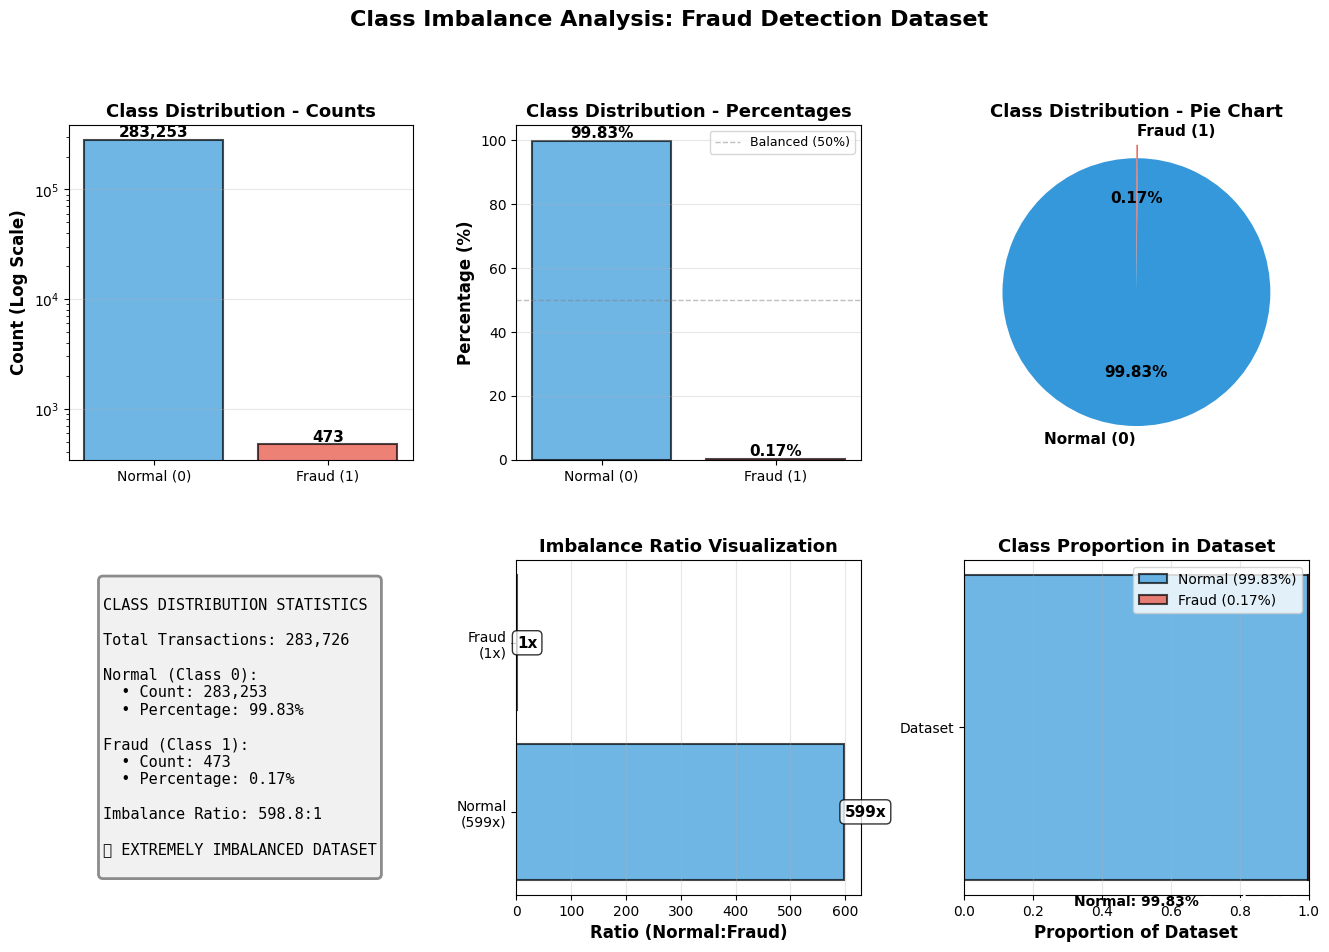


3. IMPLICATIONS FOR MODELING

🔴 CHALLENGES DUE TO CLASS IMBALANCE:

1. MODEL PERFORMANCE METRICS:
   • Accuracy is misleading: A model predicting all transactions as 'Normal' 
     would achieve 99.83% accuracy
   • Focus on: Precision, Recall, F1-Score, ROC-AUC, PR-AUC
   • Use confusion matrix to understand true/false positives/negatives

2. MODEL TRAINING CHALLENGES:
   • Models will be biased toward predicting the majority class (Normal)
   • Risk of poor generalization on fraud cases
   • Standard algorithms may ignore minority class patterns

3. DATA REQUIREMENTS:
   • Need sufficient fraud samples for model to learn patterns
   • Current fraud samples: 473 (may be limited for complex models)
   • Consider stratified sampling for train/test splits

4. RECOMMENDED APPROACHES (to be applied in Feature Engineering):
   • Resampling Techniques:
     - Random Under Sampling (RUS): Reduce majority class
     - Random Over Sampling (ROS): Duplicate minority class
     - SMOTE: Create s

In [ ]:
# ============================================================================
# Class Imbalance Analysis: Description, Visualization, and Implications
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)

# Calculate class distribution
class_counts = df['Class'].value_counts().sort_index()
class_labels = ['Normal (0)', 'Fraud (1)']
percentages = (class_counts / len(df)) * 100
imbalance_ratio = class_counts[0] / class_counts[1]

# ============================================================================
# 1. DESCRIPTION
# ============================================================================

print("\n" + "="*70)
print("1. CLASS DISTRIBUTION DESCRIPTION")
print("="*70)
print(f"\nTotal Transactions: {len(df):,}")
print(f"\nClass Distribution:")
print(f"  Normal (Class 0): {class_counts[0]:,} transactions ({percentages[0]:.2f}%)")
print(f"  Fraud (Class 1):   {class_counts[1]:,} transactions ({percentages[1]:.2f}%)")
print(f"\nImbalance Ratio: {imbalance_ratio:.1f}:1")
print(f"  → For every 1 fraud transaction, there are {imbalance_ratio:.0f} normal transactions")

print(f"\n{'='*70}")
print("SEVERITY ASSESSMENT")
print("="*70)
if imbalance_ratio > 100:
    severity = "EXTREMELY IMBALANCED"
    color_indicator = "🔴"
elif imbalance_ratio > 10:
    severity = "HIGHLY IMBALANCED"
    color_indicator = "🟠"
elif imbalance_ratio > 5:
    severity = "MODERATELY IMBALANCED"
    color_indicator = "🟡"
else:
    severity = "SLIGHTLY IMBALANCED"
    color_indicator = "🟢"

print(f"{color_indicator} This dataset is {severity}")
print(f"   Fraud represents only {percentages[1]:.3f}% of all transactions")
print(f"   This is typical for fraud detection datasets where fraud is rare")

# ============================================================================
# 2. VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("2. CLASS DISTRIBUTION VISUALIZATION")
print("="*70)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Count bar chart (log scale for visibility)
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(class_labels, class_counts.values, 
                color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count (Log Scale)', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution - Counts', fontsize=13, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
for i, (bar, count) in enumerate(zip(bars1, class_counts.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Percentage bar chart
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(class_labels, percentages.values, 
                color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Class Distribution - Percentages', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Balanced (50%)')
for i, (bar, pct) in enumerate(zip(bars2, percentages.values)):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

# 3. Pie chart
ax3 = fig.add_subplot(gs[0, 2])
colors = ['#3498db', '#e74c3c']
explode = (0, 0.1)  # Explode fraud slice for emphasis
wedges, texts, autotexts = ax3.pie(class_counts.values, labels=class_labels, 
                                   autopct='%1.2f%%', colors=colors, explode=explode,
                                   startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax3.set_title('Class Distribution - Pie Chart', fontsize=13, fontweight='bold')

# 4. Statistics summary
ax4 = fig.add_subplot(gs[1, 0])
ax4.axis('off')
stats_text = f"""
CLASS DISTRIBUTION STATISTICS

Total Transactions: {len(df):,}

Normal (Class 0):
  • Count: {class_counts[0]:,}
  • Percentage: {percentages[0]:.2f}%

Fraud (Class 1):
  • Count: {class_counts[1]:,}
  • Percentage: {percentages[1]:.2f}%

Imbalance Ratio: {imbalance_ratio:.1f}:1

{color_indicator} {severity} DATASET
"""
ax4.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', 
         facecolor='#f0f0f0', alpha=0.9, edgecolor='gray', linewidth=2))

# 5. Imbalance ratio visualization
ax5 = fig.add_subplot(gs[1, 1])
ratio_data = [imbalance_ratio, 1]
ratio_labels = [f'Normal\n({imbalance_ratio:.0f}x)', 'Fraud\n(1x)']
bars5 = ax5.barh(ratio_labels, ratio_data, 
                 color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax5.set_xlabel('Ratio (Normal:Fraud)', fontsize=12, fontweight='bold')
ax5.set_title('Imbalance Ratio Visualization', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars5, ratio_data):
    ax5.text(bar.get_width(), bar.get_y() + bar.get_height()/2.,
             f'{val:.0f}x', ha='left', va='center', fontsize=11, fontweight='bold', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 6. Class proportion comparison
ax6 = fig.add_subplot(gs[1, 2])
# Create a visual representation of the imbalance
normal_prop = percentages[0] / 100
fraud_prop = percentages[1] / 100

# Stacked bar showing proportions
ax6.barh(['Dataset'], [normal_prop], left=0, color='#3498db', alpha=0.7, 
         label=f'Normal ({percentages[0]:.2f}%)', edgecolor='black', linewidth=1.5)
ax6.barh(['Dataset'], [fraud_prop], left=normal_prop, color='#e74c3c', alpha=0.7,
         label=f'Fraud ({percentages[1]:.2f}%)', edgecolor='black', linewidth=1.5)
ax6.set_xlim(0, 1)
ax6.set_xlabel('Proportion of Dataset', fontsize=12, fontweight='bold')
ax6.set_title('Class Proportion in Dataset', fontsize=13, fontweight='bold')
ax6.legend(loc='upper right', fontsize=10)
ax6.grid(True, alpha=0.3, axis='x')
# Add text annotation
ax6.text(0.5, 0, f'Normal: {percentages[0]:.2f}%', ha='center', va='top', 
         fontsize=10, fontweight='bold', transform=ax6.transAxes)
ax6.text(0.99, 0, f'Fraud: {percentages[1]:.2f}%', ha='right', va='top',
         fontsize=10, fontweight='bold', transform=ax6.transAxes, color='white')

fig.suptitle('Class Imbalance Analysis: Fraud Detection Dataset', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# 3. IMPLICATIONS FOR MODELING
# ============================================================================

print("\n" + "="*70)
print("3. IMPLICATIONS FOR MODELING")
print("="*70)

print(f"""
{color_indicator} CHALLENGES DUE TO CLASS IMBALANCE:

1. MODEL PERFORMANCE METRICS:
   • Accuracy is misleading: A model predicting all transactions as 'Normal' 
     would achieve {percentages[0]:.2f}% accuracy
   • Focus on: Precision, Recall, F1-Score, ROC-AUC, PR-AUC
   • Use confusion matrix to understand true/false positives/negatives

2. MODEL TRAINING CHALLENGES:
   • Models will be biased toward predicting the majority class (Normal)
   • Risk of poor generalization on fraud cases
   • Standard algorithms may ignore minority class patterns

3. DATA REQUIREMENTS:
   • Need sufficient fraud samples for model to learn patterns
   • Current fraud samples: {class_counts[1]:,} (may be limited for complex models)
   • Consider stratified sampling for train/test splits

4. RECOMMENDED APPROACHES (to be applied in Feature Engineering):
   • Resampling Techniques:
     - Random Under Sampling (RUS): Reduce majority class
     - Random Over Sampling (ROS): Duplicate minority class
     - SMOTE: Create synthetic fraud samples
   • Class Weights: Penalize misclassification of fraud more heavily
   • Ensemble Methods: Combine multiple models
   • Cost-Sensitive Learning: Assign higher cost to fraud misclassification

5. BUSINESS IMPACT:
   • False Negatives (missed fraud) are costly: Financial losses
   • False Positives (false alarms) are less costly: Customer inconvenience
   • Optimize for Recall (catch as many fraud cases as possible)
   • Consider precision-recall trade-off based on business needs

6. EVALUATION STRATEGY:
   • Use stratified k-fold cross-validation
   • Monitor both precision and recall
   • Use ROC-AUC and PR-AUC (PR-AUC is better for imbalanced data)
   • Analyze confusion matrix for each model
""")

print("="*70)
print("NEXT STEPS")
print("="*70)
print("""
✓ Class imbalance identified and documented
✓ Implications understood
→ Proceed to Feature Engineering notebook (02) to:
  - Apply resampling techniques (RUS, ROS, SMOTE)
  - Implement class weights
  - Prepare balanced datasets for modeling
""")
print("="*70)


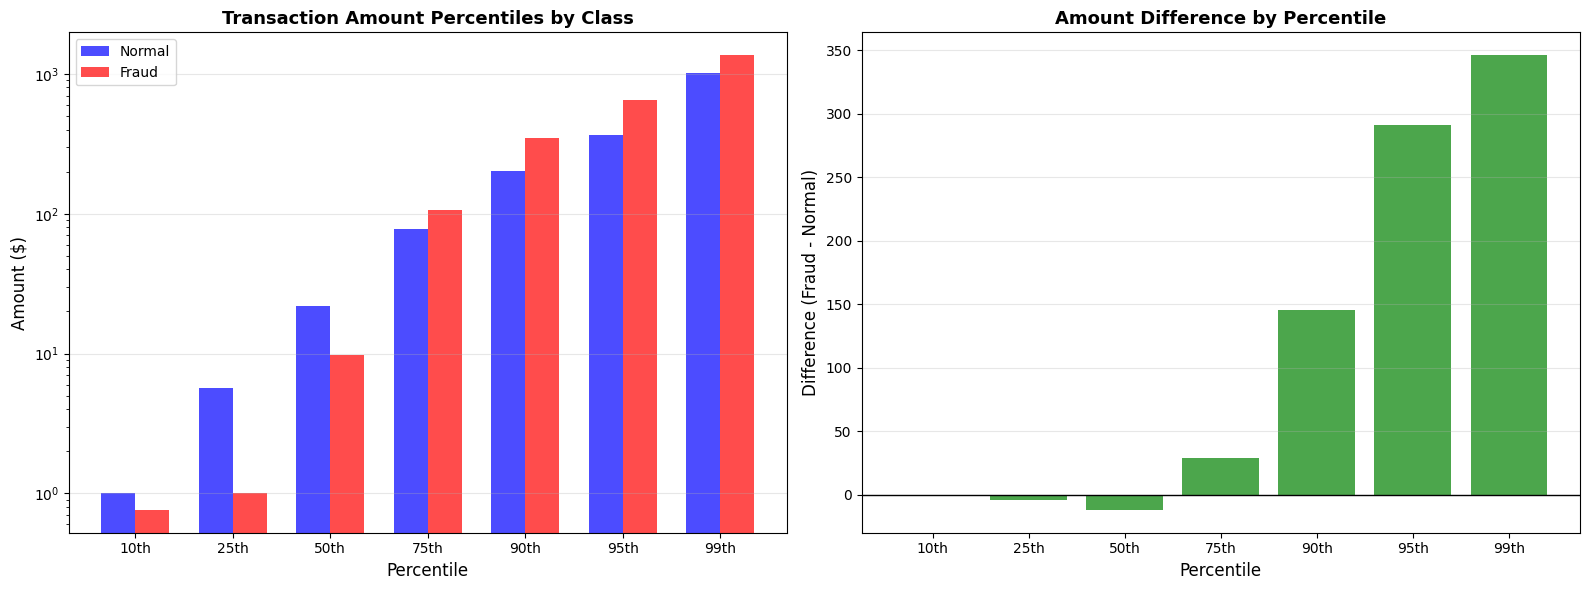


Amount Percentiles Comparison:
Percentile    Normal     Fraud  Difference
      10th    1.0000    0.7600     -0.2400
      25th    5.6700    1.0000     -4.6700
      50th   22.0000    9.8200    -12.1800
      75th   77.4600  105.8900     28.4300
      90th  203.0000  348.6520    145.6520
      95th  365.0000  655.8200    290.8200
      99th 1018.0576 1364.1368    346.0792


In [ ]:
# ============================================================================
# Amount Percentiles Analysis
# ============================================================================

percentiles = [10, 25, 50, 75, 90, 95, 99]
normal_percentiles = [np.percentile(df[df['Class'] == 0]['Amount'], p) for p in percentiles]
fraud_percentiles = [np.percentile(df[df['Class'] == 1]['Amount'], p) for p in percentiles]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Percentile comparison
x_pos = np.arange(len(percentiles))
width = 0.35
axes[0].bar(x_pos - width/2, normal_percentiles, width, label='Normal', 
            color='blue', alpha=0.7)
axes[0].bar(x_pos + width/2, fraud_percentiles, width, label='Fraud', 
            color='red', alpha=0.7)
axes[0].set_xlabel('Percentile', fontsize=12)
axes[0].set_ylabel('Amount ($)', fontsize=12)
axes[0].set_title('Transaction Amount Percentiles by Class', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'{p}th' for p in percentiles])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_yscale('log')

# Percentile difference
percentile_diff = [f - n for f, n in zip(fraud_percentiles, normal_percentiles)]
axes[1].bar(x_pos, percentile_diff, color='green', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Percentile', fontsize=12)
axes[1].set_ylabel('Difference (Fraud - Normal)', fontsize=12)
axes[1].set_title('Amount Difference by Percentile', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'{p}th' for p in percentiles])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
percentile_df = pd.DataFrame({
    'Percentile': [f'{p}th' for p in percentiles],
    'Normal': normal_percentiles,
    'Fraud': fraud_percentiles,
    'Difference': percentile_diff
})
print("\nAmount Percentiles Comparison:")
print(percentile_df.to_string(index=False))

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/1569429975.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/1569429975.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')


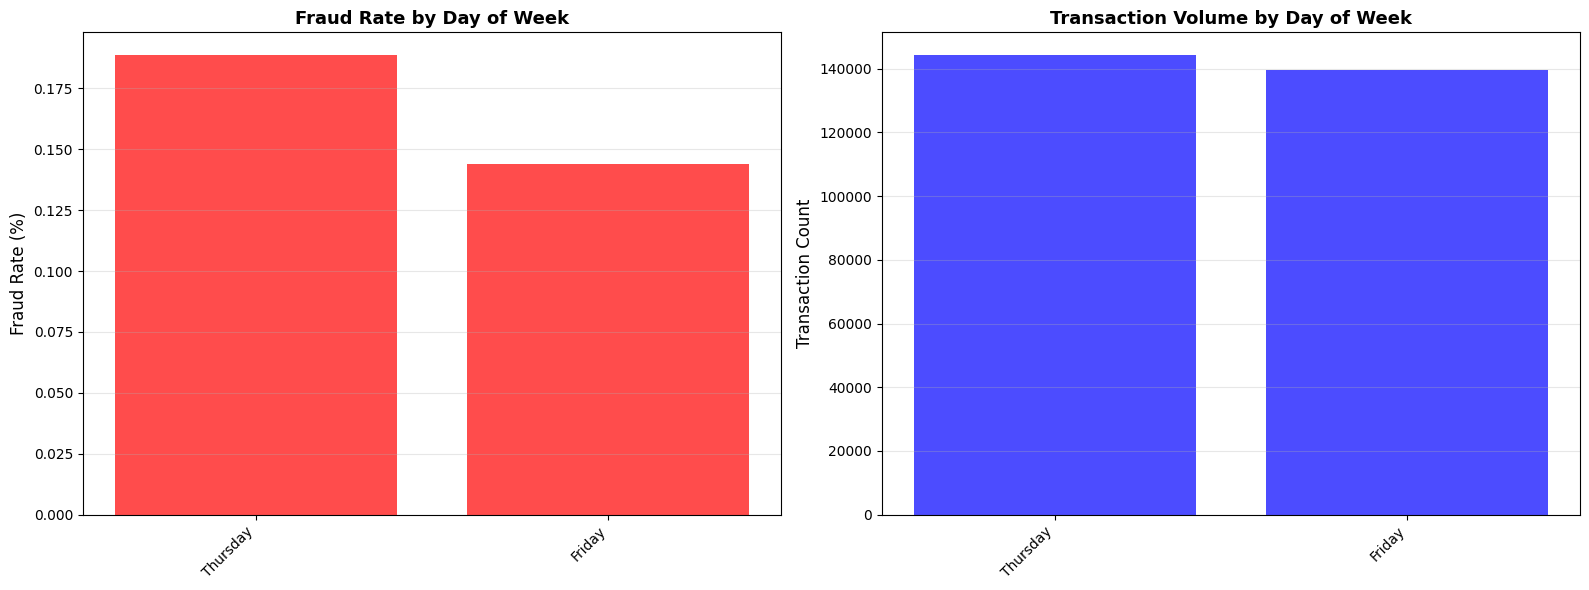

In [ ]:
# ============================================================================
# Temporal Patterns: Day of Week Analysis
# ============================================================================

# Convert Time to datetime (assuming Time is seconds from first transaction)
# You may need to adjust based on your Time column format
df['DayOfWeek'] = pd.to_datetime(df['Time'], unit='s').dt.day_name()

# Fraud rate by day of week
fraud_by_day = df.groupby('DayOfWeek')['Class'].agg(['count', 'sum', 'mean'])
fraud_by_day['fraud_rate'] = fraud_by_day['mean'] * 100
fraud_by_day = fraud_by_day.sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_by_day_ordered = fraud_by_day.reindex([d for d in day_order if d in fraud_by_day.index])

axes[0].bar(fraud_by_day_ordered.index, fraud_by_day_ordered['fraud_rate'], 
            color='red', alpha=0.7)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[0].set_title('Fraud Rate by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Transaction volume by day
axes[1].bar(fraud_by_day_ordered.index, fraud_by_day_ordered['count'], 
            color='blue', alpha=0.7)
axes[1].set_ylabel('Transaction Count', fontsize=12)
axes[1].set_title('Transaction Volume by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

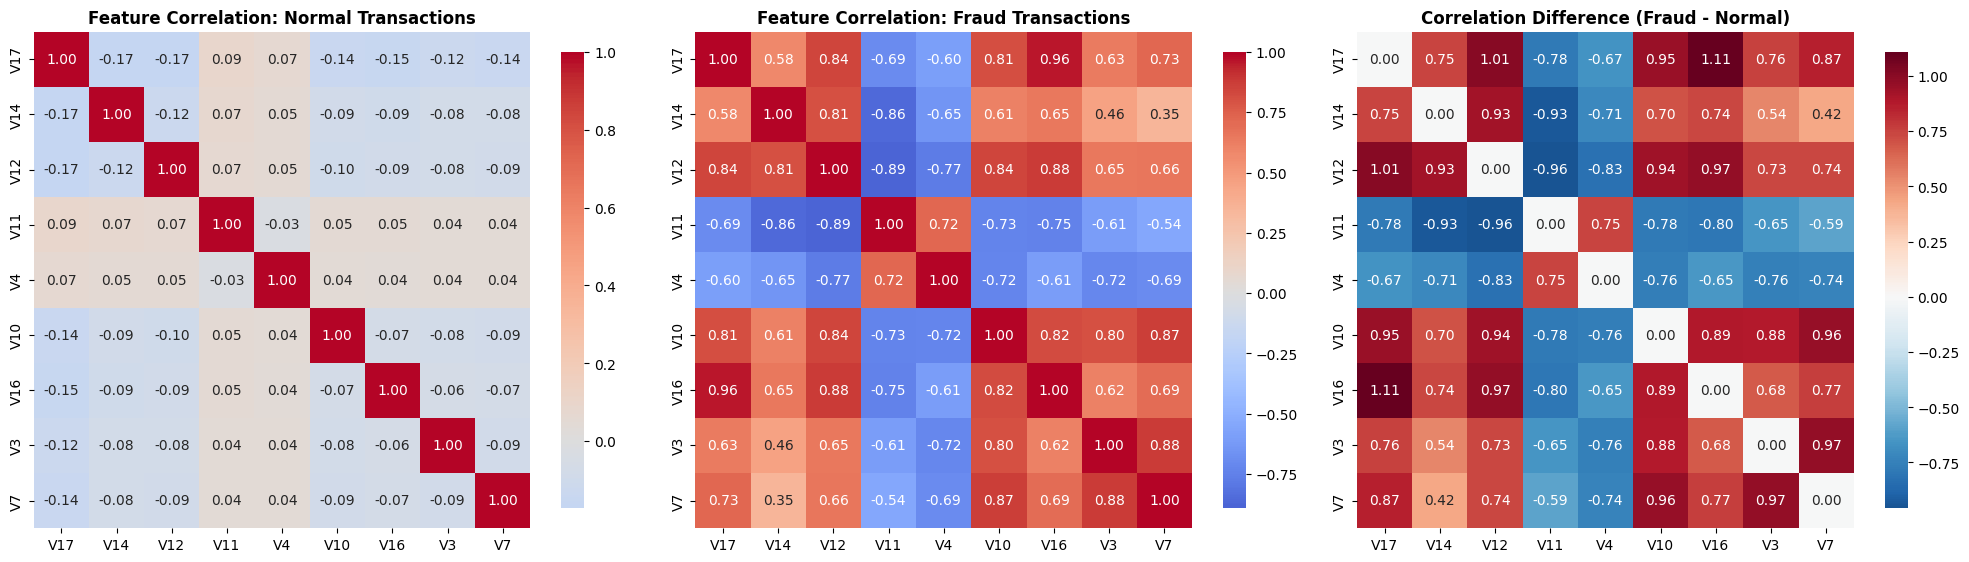

In [ ]:
# ============================================================================
# Feature Interaction Analysis
# ============================================================================

# Select top correlated features
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']

# Calculate interaction: correlation between features for fraud vs normal
normal_corr = df[df['Class'] == 0][top_features].corr()
fraud_corr = df[df['Class'] == 1][top_features].corr()
interaction_diff = fraud_corr - normal_corr

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Normal transactions correlation
sns.heatmap(normal_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Feature Correlation: Normal Transactions', fontsize=12, fontweight='bold')

# Fraud transactions correlation
sns.heatmap(fraud_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation: Fraud Transactions', fontsize=12, fontweight='bold')

# Difference (shows how relationships change)
sns.heatmap(interaction_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[2], cbar_kws={"shrink": 0.8})
axes[2].set_title('Correlation Difference (Fraud - Normal)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

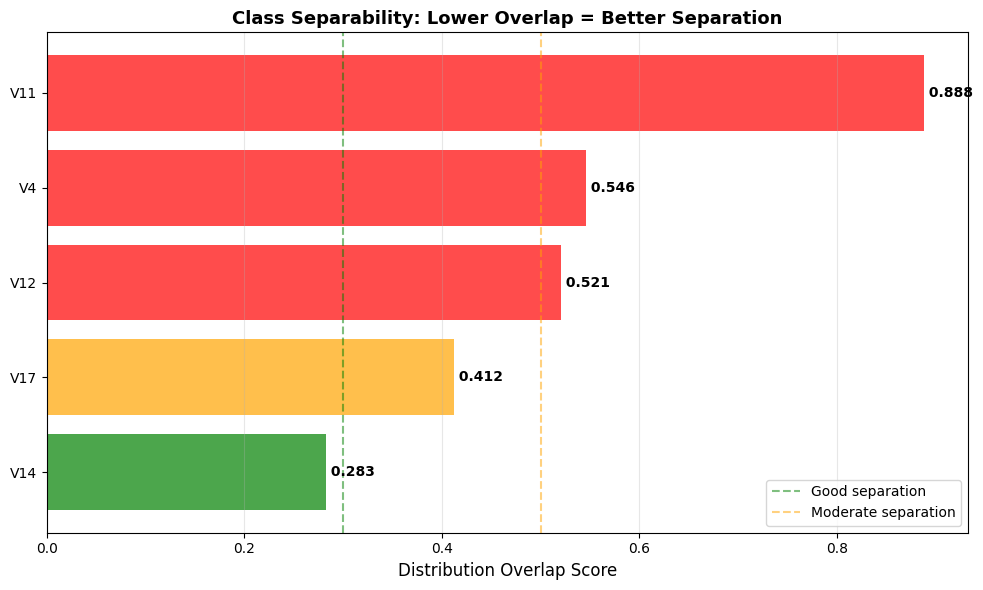


Class Separability Analysis:
Lower overlap = better feature for distinguishing fraud
Feature  Overlap_Score
    V14       0.283001
    V17       0.411962
    V12       0.520805
     V4       0.546128
    V11       0.888167


In [ ]:
# ============================================================================
# Class Separability Analysis
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
overlap_scores = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Calculate overlap using histogram intersection
    hist_normal, bins = np.histogram(normal_data, bins=50, density=True)
    hist_fraud, _ = np.histogram(fraud_data, bins=bins, density=True)
    
    # Histogram intersection (overlap measure)
    overlap = np.minimum(hist_normal, hist_fraud).sum()
    overlap_scores.append(overlap)

overlap_df = pd.DataFrame({
    'Feature': top_features,
    'Overlap_Score': overlap_scores
}).sort_values('Overlap_Score')

plt.figure(figsize=(10, 6))
bars = plt.barh(overlap_df['Feature'], overlap_df['Overlap_Score'], 
                color=['green' if s < 0.3 else 'orange' if s < 0.5 else 'red' 
                      for s in overlap_df['Overlap_Score']], alpha=0.7)
plt.xlabel('Distribution Overlap Score', fontsize=12)
plt.title('Class Separability: Lower Overlap = Better Separation', fontsize=13, fontweight='bold')
plt.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Good separation')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate separation')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

for bar, score in zip(bars, overlap_df['Overlap_Score']):
    plt.text(score, bar.get_y() + bar.get_height()/2, 
             f' {score:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Separability Analysis:")
print("Lower overlap = better feature for distinguishing fraud")
print(overlap_df.to_string(index=False))

# Handling Class Imbalance / Class Imbalance Analysis


In [ ]:
# Class Imbalance Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Prepare data for imbalance handling
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split into train and test sets (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())


Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training set class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test set class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


# DONE

# Additional Exploratory Analysis


# Save Cleaned Data for Next Notebook

Before moving to feature engineering, we'll save the cleaned dataset so it can be loaded in the next notebook.


In [ ]:
# Save cleaned dataset for use in feature engineering notebook
import os

# Create data directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save cleaned dataframe
df.to_csv('../data/processed/creditcard_cleaned.csv', index=False)

print(f"Cleaned dataset saved successfully!")
print(f"Shape: {df.shape}")
print(f"Class distribution:")
print(df['Class'].value_counts())
print(f"\nFile saved to: ../data/processed/creditcard_cleaned.csv")


# Summary and Next Steps

## Key Findings:
1. **Data Quality**: No missing values detected
2. **Class Imbalance**: Severe imbalance (~0.17% fraud rate)
3. **Imbalance Handling Options**:
   - **SMOTE**: Creates synthetic fraud samples to balance classes
   - **Class Weights**: Penalizes misclassification of minority class more heavily
4. **Feature Characteristics**: 
   - V1-V28 are PCA components (already standardized)
   - Time and Amount may need scaling
   - Strong correlations exist between certain features and fraud

## Recommendations:
- Use stratified train/test splits to maintain class distribution
- Consider both SMOTE and class weights approaches
- Focus on precision/recall metrics rather than accuracy (due to imbalance)
- Consider feature scaling for Time and Amount if using distance-based models


# Resampling

In [ ]:
# Method 1: Calculate class weights for use in models that support it
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights (balanced):")
print(f"Class 0 (Normal): {class_weight_dict[0]:.4f}")
print(f"Class 1 (Fraud): {class_weight_dict[1]:.4f}")
print(f"\nThis means fraud samples will be weighted {class_weight_dict[1]/class_weight_dict[0]:.2f}x more than normal samples")


Class weights (balanced):
Class 0 (Normal): 0.5008
Class 1 (Fraud): 300.2381

This means fraud samples will be weighted 599.48x more than normal samples


In [ ]:
# ============================================================================
# Handling Class Imbalance: Comparing Sampling Methods
# ============================================================================
# We'll test different resampling techniques to understand their effects
# without modifying the original training data (X_train, y_train remain unchanged)

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Brief explanation of methods (since you know the benefits/drawbacks)
print("="*70)
print("SAMPLING METHODS OVERVIEW")
print("="*70)
print("""
1. Random Under Sampling (RUS):
   - Reduces majority class samples
   - Benefit: Computationally efficient, faster training
   - Drawback: Loses information by discarding data

2. Random Over Sampling (ROS):
   - Duplicates minority class samples
   - Benefit: Simple and straightforward
   - Drawback: Training on duplicates can lead to overfitting

3. SMOTE (Synthetic Minority Oversampling Technique):
   - Creates synthetic minority class samples
   - Benefit: More realistic dataset, avoids exact duplicates
   - Drawback: Training on 'synthetic' data
""")
print("="*70)

SAMPLING METHODS OVERVIEW

1. Random Under Sampling (RUS):
   - Reduces majority class samples
   - Benefit: Computationally efficient, faster training
   - Drawback: Loses information by discarding data

2. Random Over Sampling (ROS):
   - Duplicates minority class samples
   - Benefit: Simple and straightforward
   - Drawback: Training on duplicates can lead to overfitting

3. SMOTE (Synthetic Minority Oversampling Technique):
   - Creates synthetic minority class samples
   - Benefit: More realistic dataset, avoids exact duplicates
   - Drawback: Training on 'synthetic' data



In [ ]:
# ============================================================================
# Apply Different Sampling Methods (Original Data Unchanged)
# ============================================================================

# Store original distribution
original_dist = Counter(y_train)
print("\nOriginal Training Set Distribution:")
print(f"  Class 0 (Normal): {original_dist[0]:,}")
print(f"  Class 1 (Fraud): {original_dist[1]:,}")
print(f"  Total: {len(y_train):,}")
print(f"  Imbalance Ratio: {original_dist[0] / original_dist[1]:.1f}:1")

# Method 1: Random Under Sampling
print("\n" + "="*70)
print("METHOD 1: Random Under Sampling (RUS)")
print("="*70)

rus = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X_train_rus, y_train_rus = rus.fit_resample(X_train.copy(), y_train.copy())

rus_dist = Counter(y_train_rus)
print(f"After RUS:")
print(f"  Class 0 (Normal): {rus_dist[0]:,}")
print(f"  Class 1 (Fraud): {rus_dist[1]:,}")
print(f"  Total: {len(y_train_rus):,}")
print(f"  Samples removed: {len(y_train) - len(y_train_rus):,}")
print(f"  Data loss: {((len(y_train) - len(y_train_rus)) / len(y_train)) * 100:.2f}%")

# Method 2: Random Over Sampling
print("\n" + "="*70)
print("METHOD 2: Random Over Sampling (ROS)")
print("="*70)

ros = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_train_ros, y_train_ros = ros.fit_resample(X_train.copy(), y_train.copy())

ros_dist = Counter(y_train_ros)
print(f"After ROS:")
print(f"  Class 0 (Normal): {ros_dist[0]:,}")
print(f"  Class 1 (Fraud): {ros_dist[1]:,}")
print(f"  Total: {len(y_train_ros):,}")
print(f"  Samples added: {len(y_train_ros) - len(y_train):,}")
print(f"  Data increase: {((len(y_train_ros) - len(y_train)) / len(y_train)) * 100:.2f}%")

# Method 3: SMOTE
print("\n" + "="*70)
print("METHOD 3: SMOTE (Synthetic Minority Oversampling)")
print("="*70)

smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train.copy(), y_train.copy())

smote_dist = Counter(y_train_smote)
print(f"After SMOTE:")
print(f"  Class 0 (Normal): {smote_dist[0]:,}")
print(f"  Class 1 (Fraud): {smote_dist[1]:,}")
print(f"  Total: {len(y_train_smote):,}")
print(f"  Samples added: {len(y_train_smote) - len(y_train):,}")
print(f"  Data increase: {((len(y_train_smote) - len(y_train)) / len(y_train)) * 100:.2f}%")

# Verify original data is unchanged
print("\n" + "="*70)
print("VERIFICATION: Original Data Unchanged")
print("="*70)
print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train distribution: {Counter(y_train)}")
print("✓ Original training data remains intact!")


Original Training Set Distribution:
  Class 0 (Normal): 226,602
  Class 1 (Fraud): 378
  Total: 226,980
  Imbalance Ratio: 599.5:1

METHOD 1: Random Under Sampling (RUS)
After RUS:
  Class 0 (Normal): 378
  Class 1 (Fraud): 378
  Total: 756
  Samples removed: 226,224
  Data loss: 99.67%

METHOD 2: Random Over Sampling (ROS)
After ROS:
  Class 0 (Normal): 226,602
  Class 1 (Fraud): 226,602
  Total: 453,204
  Samples added: 226,224
  Data increase: 99.67%

METHOD 3: SMOTE (Synthetic Minority Oversampling)
After SMOTE:
  Class 0 (Normal): 226,602
  Class 1 (Fraud): 226,602
  Total: 453,204
  Samples added: 226,224
  Data increase: 99.67%

VERIFICATION: Original Data Unchanged
Original X_train shape: (226980, 30)
Original y_train distribution: Counter({0: 226602, 1: 378})
✓ Original training data remains intact!


In [ ]:
# ============================================================================
# Comparison: Class Distribution Before and After
# ============================================================================

# Create comparison DataFrame
comparison_data = {
    'Method': ['Original', 'RUS', 'ROS', 'SMOTE'],
    'Class_0_Count': [original_dist[0], rus_dist[0], ros_dist[0], smote_dist[0]],
    'Class_1_Count': [original_dist[1], rus_dist[1], ros_dist[1], smote_dist[1]],
    'Total_Samples': [len(y_train), len(y_train_rus), len(y_train_ros), len(y_train_smote)],
    'Class_0_Pct': [original_dist[0]/len(y_train)*100, 
                    rus_dist[0]/len(y_train_rus)*100,
                    ros_dist[0]/len(y_train_ros)*100,
                    smote_dist[0]/len(y_train_smote)*100],
    'Class_1_Pct': [original_dist[1]/len(y_train)*100,
                    rus_dist[1]/len(y_train_rus)*100,
                    ros_dist[1]/len(y_train_ros)*100,
                    smote_dist[1]/len(y_train_smote)*100]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Imbalance_Ratio'] = comparison_df['Class_0_Count'] / comparison_df['Class_1_Count']

print("\n" + "="*70)
print("COMPARISON TABLE: Class Distribution by Method")
print("="*70)
print(comparison_df.to_string(index=False))


COMPARISON TABLE: Class Distribution by Method
  Method  Class_0_Count  Class_1_Count  Total_Samples  Class_0_Pct  Class_1_Pct  Imbalance_Ratio
Original         226602            378         226980    99.833466     0.166534        599.47619
     RUS            378            378            756    50.000000    50.000000          1.00000
     ROS         226602         226602         453204    50.000000    50.000000          1.00000
   SMOTE         226602         226602         453204    50.000000    50.000000          1.00000


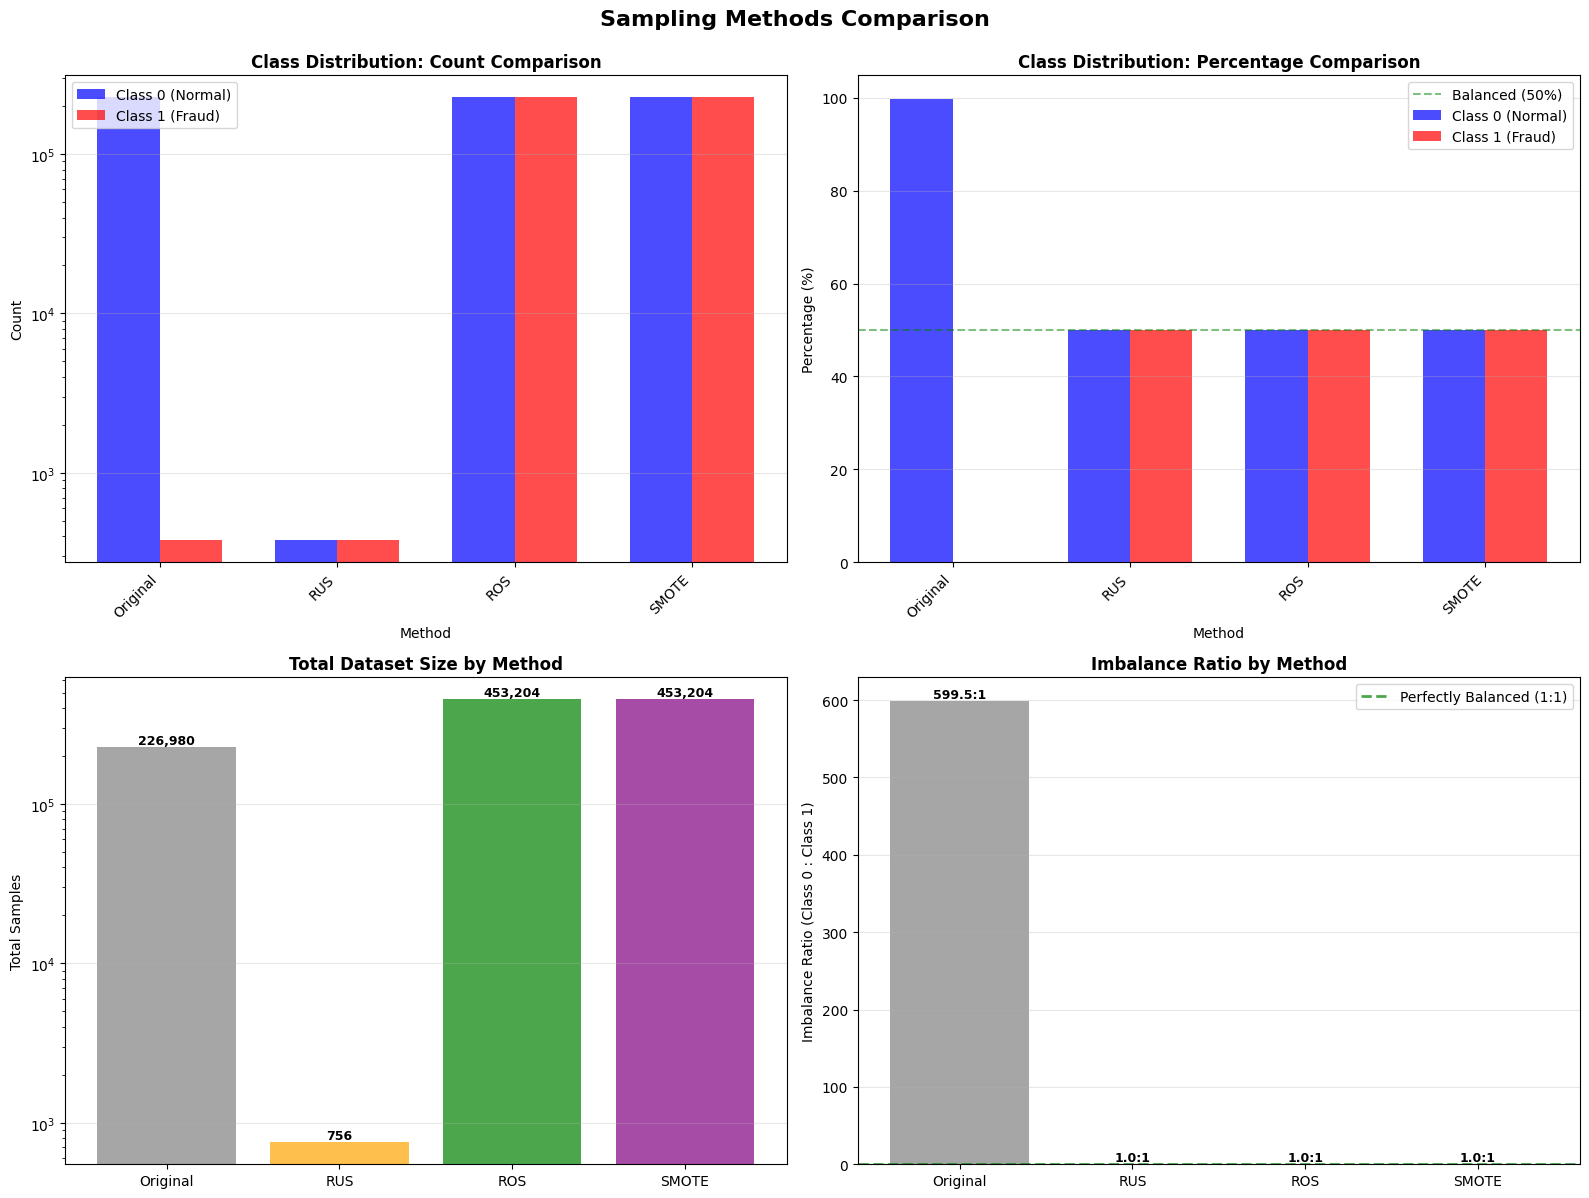

In [ ]:
# ============================================================================
# Visualization: Class Distribution Comparison
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Count comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['Class_0_Count'], width, 
        label='Class 0 (Normal)', color='blue', alpha=0.7)
ax1.bar(x_pos + width/2, comparison_df['Class_1_Count'], width,
        label='Class 1 (Fraud)', color='red', alpha=0.7)
ax1.set_xlabel('Method')
ax1.set_ylabel('Count')
ax1.set_title('Class Distribution: Count Comparison', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Method'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yscale('log')  # Log scale for better visibility

# 2. Percentage comparison
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, comparison_df['Class_0_Pct'], width,
        label='Class 0 (Normal)', color='blue', alpha=0.7)
ax2.bar(x_pos + width/2, comparison_df['Class_1_Pct'], width,
        label='Class 1 (Fraud)', color='red', alpha=0.7)
ax2.set_xlabel('Method')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Class Distribution: Percentage Comparison', fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Method'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Balanced (50%)')
ax2.legend()

# 3. Total samples comparison
ax3 = axes[1, 0]
bars = ax3.bar(comparison_df['Method'], comparison_df['Total_Samples'], 
               color=['gray', 'orange', 'green', 'purple'], alpha=0.7)
ax3.set_ylabel('Total Samples')
ax3.set_title('Total Dataset Size by Method', fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')
# Add value labels
for bar, val in zip(bars, comparison_df['Total_Samples']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Imbalance ratio comparison
ax4 = axes[1, 1]
bars = ax4.bar(comparison_df['Method'], comparison_df['Imbalance_Ratio'],
               color=['gray', 'orange', 'green', 'purple'], alpha=0.7)
ax4.set_ylabel('Imbalance Ratio (Class 0 : Class 1)')
ax4.set_title('Imbalance Ratio by Method', fontweight='bold')
ax4.axhline(y=1.0, color='green', linestyle='--', linewidth=2, 
            label='Perfectly Balanced (1:1)', alpha=0.7)
ax4.grid(True, alpha=0.3, axis='y')
ax4.legend()
# Add value labels
for bar, val in zip(bars, comparison_df['Imbalance_Ratio']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}:1', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Sampling Methods Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

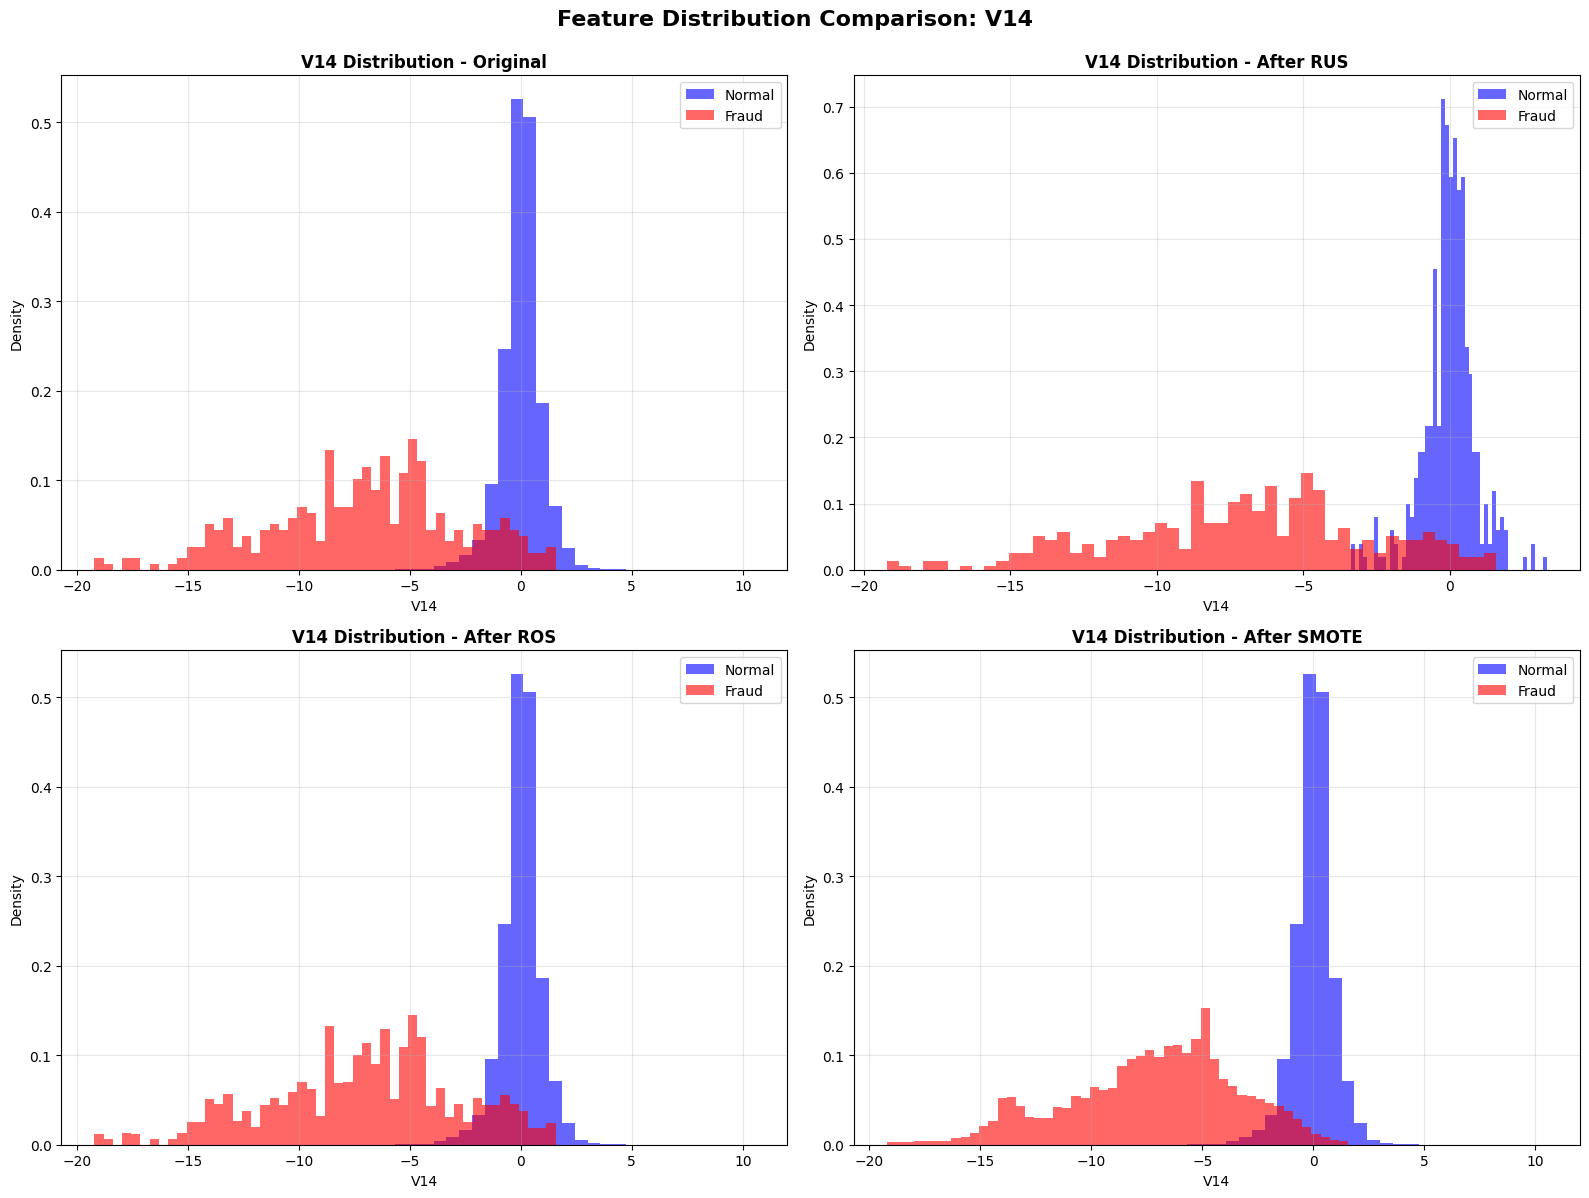

In [ ]:
# ============================================================================
# Visualization: Feature Distribution Comparison (Using Key Feature)
# ============================================================================
# Compare how each method affects the distribution of a key feature (V14)

key_feature = 'V14'  # One of the most correlated features with fraud

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original data
axes[0, 0].hist(X_train[y_train == 0][key_feature], bins=50, alpha=0.6, 
                label='Normal', color='blue', density=True)
axes[0, 0].hist(X_train[y_train == 1][key_feature], bins=50, alpha=0.6,
                label='Fraud', color='red', density=True)
axes[0, 0].set_title(f'{key_feature} Distribution - Original', fontweight='bold')
axes[0, 0].set_xlabel(key_feature)
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RUS
axes[0, 1].hist(X_train_rus[y_train_rus == 0][key_feature], bins=50, alpha=0.6,
                label='Normal', color='blue', density=True)
axes[0, 1].hist(X_train_rus[y_train_rus == 1][key_feature], bins=50, alpha=0.6,
                label='Fraud', color='red', density=True)
axes[0, 1].set_title(f'{key_feature} Distribution - After RUS', fontweight='bold')
axes[0, 1].set_xlabel(key_feature)
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ROS
axes[1, 0].hist(X_train_ros[y_train_ros == 0][key_feature], bins=50, alpha=0.6,
                label='Normal', color='blue', density=True)
axes[1, 0].hist(X_train_ros[y_train_ros == 1][key_feature], bins=50, alpha=0.6,
                label='Fraud', color='red', density=True)
axes[1, 0].set_title(f'{key_feature} Distribution - After ROS', fontweight='bold')
axes[1, 0].set_xlabel(key_feature)
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# SMOTE
axes[1, 1].hist(X_train_smote[y_train_smote == 0][key_feature], bins=50, alpha=0.6,
               label='Normal', color='blue', density=True)
axes[1, 1].hist(X_train_smote[y_train_smote == 1][key_feature], bins=50, alpha=0.6,
               label='Fraud', color='red', density=True)
axes[1, 1].set_title(f'{key_feature} Distribution - After SMOTE', fontweight='bold')
axes[1, 1].set_xlabel(key_feature)
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Feature Distribution Comparison: {key_feature}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# Summary and Recommendations
# ============================================================================

print("\n" + "="*70)
print("SUMMARY AND RECOMMENDATIONS")
print("="*70)
print(f"""
Based on the comparison:

1. RANDOM UNDER SAMPLING (RUS):
   - Reduced dataset from {len(y_train):,} to {len(y_train_rus):,} samples
   - Data loss: {((len(y_train) - len(y_train_rus)) / len(y_train)) * 100:.1f}%
   - Best for: Quick experiments, limited computational resources
   - Trade-off: Significant information loss

2. RANDOM OVER SAMPLING (ROS):
   - Increased dataset from {len(y_train):,} to {len(y_train_ros):,} samples
   - Data increase: {((len(y_train_ros) - len(y_train)) / len(y_train)) * 100:.1f}%
   - Best for: Simple baseline, when computational resources allow
   - Trade-off: Exact duplicates may cause overfitting

3. SMOTE:
   - Increased dataset from {len(y_train):,} to {len(y_train_smote):,} samples
   - Data increase: {((len(y_train_smote) - len(y_train)) / len(y_train)) * 100:.1f}%
   - Best for: Production models, when synthetic data is acceptable
   - Trade-off: Synthetic samples may not perfectly represent real fraud patterns

NEXT STEPS:
- Test each method with your chosen model(s) to see which performs best
- Consider using cross-validation to evaluate performance
- Original data (X_train, y_train) remains available for comparison
- Choose method based on: model performance, computational constraints, and business requirements
""")
print("="*70)


SUMMARY AND RECOMMENDATIONS

Based on the comparison:

1. RANDOM UNDER SAMPLING (RUS):
   - Reduced dataset from 226,980 to 756 samples
   - Data loss: 99.7%
   - Best for: Quick experiments, limited computational resources
   - Trade-off: Significant information loss

2. RANDOM OVER SAMPLING (ROS):
   - Increased dataset from 226,980 to 453,204 samples
   - Data increase: 99.7%
   - Best for: Simple baseline, when computational resources allow
   - Trade-off: Exact duplicates may cause overfitting

3. SMOTE:
   - Increased dataset from 226,980 to 453,204 samples
   - Data increase: 99.7%
   - Best for: Production models, when synthetic data is acceptable
   - Trade-off: Synthetic samples may not perfectly represent real fraud patterns

NEXT STEPS:
- Test each method with your chosen model(s) to see which performs best
- Consider using cross-validation to evaluate performance
- Original data (X_train, y_train) remains available for comparison
- Choose method based on: model performanc

In [ ]:
# Method 2: Apply SMOTE (Synthetic Minority Oversampling Technique)
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:")
print(f"Class distribution: {Counter(y_train)}")

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Class distribution: {Counter(y_train_smote)}")
print(f"New training set shape: {X_train_smote.shape}")
print(f"Original training set shape: {X_train.shape}")
print(f"Samples added: {X_train_smote.shape[0] - X_train.shape[0]}")


Before SMOTE:
Class distribution: Counter({0: 226602, 1: 378})

After SMOTE:
Class distribution: Counter({0: 226602, 1: 226602})
New training set shape: (453204, 30)
Original training set shape: (226980, 30)
Samples added: 226224


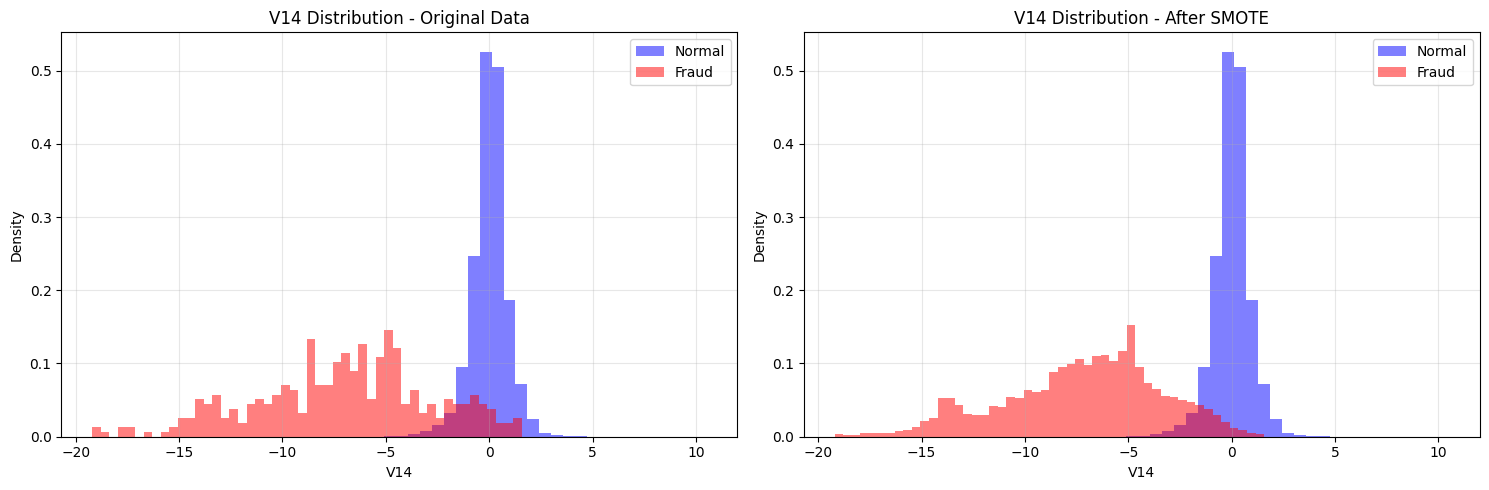

In [ ]:
# Visualize the effect of SMOTE on feature distributions
# Compare original vs SMOTE-augmented data for a key feature
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original data
axes[0].hist(X_train[y_train == 0]['V14'], bins=50, alpha=0.5, label='Normal', color='blue', density=True)
axes[0].hist(X_train[y_train == 1]['V14'], bins=50, alpha=0.5, label='Fraud', color='red', density=True)
axes[0].set_title('V14 Distribution - Original Data')
axes[0].set_xlabel('V14')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# SMOTE-augmented data
axes[1].hist(X_train_smote[y_train_smote == 0]['V14'], bins=50, alpha=0.5, label='Normal', color='blue', density=True)
axes[1].hist(X_train_smote[y_train_smote == 1]['V14'], bins=50, alpha=0.5, label='Fraud', color='red', density=True)
axes[1].set_title('V14 Distribution - After SMOTE')
axes[1].set_xlabel('V14')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Statistical summary by class
print("Summary statistics for Normal transactions:")
print(df[df['Class'] == 0][['Amount', 'Time']].describe())

print("\n" + "="*50)
print("Summary statistics for Fraud transactions:")
print(df[df['Class'] == 1][['Amount', 'Time']].describe())


In [ ]:
# Check for any anomalies in the data
print("Data Quality Checks:")
print(f"1. Negative amounts: {(df['Amount'] < 0).sum()}")
print(f"2. Zero amounts: {(df['Amount'] == 0).sum()}")
print(f"3. Negative time: {(df['Time'] < 0).sum()}")
print(f"4. Class values other than 0/1: {((df['Class'] != 0) & (df['Class'] != 1)).sum()}")

# Check if fraud transactions have any distinct patterns
print(f"\nFraud transaction patterns:")
print(f"- Average amount: ${df[df['Class'] == 1]['Amount'].mean():.2f}")
print(f"- Median amount: ${df[df['Class'] == 1]['Amount'].median():.2f}")
print(f"- Max amount: ${df[df['Class'] == 1]['Amount'].max():.2f}")
print(f"- Min amount: ${df[df['Class'] == 1]['Amount'].min():.2f}")


In [ ]:
# Feature scaling considerations
# Check the scale of different features
print("Feature scales (std deviation):")
print(df[['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]].std().describe())

# Note: V1-V28 are already PCA-transformed and likely standardized
# Time and Amount may need scaling
print("\nNote: V1-V28 appear to be PCA components (likely already standardized)")
print("Time and Amount may need scaling for some models")
